In [1]:
# importing packages
import pyomo.environ as pyo
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.interpolate import griddata
import math
import scipy.stats as stats
from scipy.optimize import fsolve, bisect
import pandas as pd
import conductivity_paper as cd
from scipy.optimize import minimize

# Conductivity of Simple Ionic Mixtures

# Double Salts Prediction

## Data for Double Salts

In [2]:
# load LiCl simulated data
data = pd.read_csv("./Data/LiCL_pH.csv")
LiCl_conc = data["LiCl_conc"]
HCl_conc_ph2 = data["HCl_conc_ph2"]
HCl_conc_ph3 = data["HCl_conc_ph3"]
HCl_conc_ph4 = data["HCl_conc_ph4"]

# number of data points
ndata = len(LiCl_conc)

## Constants

In [3]:
# temperature in K
T = 298.15

# diffusion coefficients at infinite dilution in m^2/s
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)
Diff_Li = 1.029 * 10**(-9)
Diff_H = 9.311 * 10**(-9)
Diff_Co = 0.732 * 10**(-9)

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3
z_Li = 1
z_H = 1
z_Co = 2

# hard sphere diameters in m
sigma_Cl = 2 * 181 * 10**(-12)
sigma_Ca = 2 * 100 * 10**(-12)
sigma_La = 2 * 118 * 10**(-12)
sigma_Na = 2 * 102 * 10**(-12)
sigma_Li = 2 * 74 * 10**(-12)
sigma_H = 2 * 37 * 10**(-12)
sigma_Co = 2 * 75 * 10**(-12)

# solvent viscosity in Pa.s
eta = 0.89 * 10**(-3)

# relative permittivity
epsilon = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Na_mol = 50.08 * 10**(-4)
lambda_0_Cl_mol = 76.31 * 10**(-4)
lambda_0_Ca_mol = 59.47 * 10**(-4)
lambda_0_La_mol = 69.7 * 10**(-4)
lambda_0_Li_mol = 38.66 * 10**(-4)
lambda_0_H_mol = 349.65 * 10**(-4)
lambda_0_Co_mol = 55 * 10**(-4)

## MSA Transport Model

### pH 2 LiCl and HCl

In [4]:
# Mean spherical approximation (MSA) transport model for multi-salt specific conductivity
def msa_transport(valency, diameters, diff_coeff, temp, eta, epsilon, lambda_0,
                  salt_1_conc, salt_2_conc=None, salt_3_conc=None):
    """Calculates the specific conductivity of single-salt, two-salt, and three-salt solutions

    Argument:
        valency: list, valency of ions in decreasing order with hydrogen ion as the last entry
        diameters: list, corresponding hard sphere diameter of the ions in m
        diff_coeff: list, corresponding diffusion coefficient of the ions at infinite dilution in m^2/s
        temp: int or float, temperature in K
        eta: int or float, viscosity in Pa.s
        epsilon: int or float, relative permittivity
        lambda_0: list, corresponding limiting molar conductivity of the ions in S.m^2/mol
        salt_1_conc = Pandas series or list, concentration of salt 1 in mM
        salt_2_conc = Pandas series or list, concentration of salt 2 in mM
        salt_3_conc = Pandas series or list, concentration of salt 3 in mM

    Returns:
        all_cond_calc_con: specific conductivity of the salt solution in milli.S/cm"""

    # constants
    Avogadros_num = 6.022 * 10 ** 23  # Avogadro's constant
    k_B = 1.381 * 10 ** (-23)  # Boltzmann constant in J/K
    charge = 1.602 * 10 ** (-19)  # elementary charge in C
    epsilon_0 = 8.854 * 10 ** (-12)  # permittivity of free space in F/m
    Faraday = 96500  # Faraday's constant in C/mol

    # number of data points
    ndata = len(salt_1_conc)

    # number of species
    n_species = len(valency)

    # species charge
    ion_charge = [valency[i] * charge for i in range(len(valency))]

    # converting molar concentrations to number density
    if salt_2_conc is None and salt_3_conc is None:
        number_density_salt_1 = [salt_1_conc[i] * Avogadros_num for i in range(ndata)]

        # valency of cation
        valency_cation = valency[1]

        # evaluating the number density of individual species
        number_density_cat_1 = number_density_salt_1
        number_density_an = [valency_cation * number_density_salt_1[i] for i in range(ndata)]
    elif salt_2_conc is not None and salt_3_conc is None:
        number_density_salt_1 = [salt_1_conc[i] * Avogadros_num for i in range(ndata)]
        number_density_salt_2 = [salt_2_conc[i] * Avogadros_num for i in range(ndata)]

        # valency of cations
        valency_cation_1 = valency[0]
        valency_cation_2 = valency[2]

        # evaluating the number density of individual species
        number_density_cat_1 = number_density_salt_1
        number_density_cat_2 = number_density_salt_2
        number_density_an = [valency_cation_1 * number_density_salt_1[i] + valency_cation_2 * number_density_salt_2[i]
                             for i in range(ndata)]

    # calculate the bulk conductivity of the salt solution
    all_cond_calc = np.zeros(ndata)
    for n in range(ndata):  # loop through the salts concentration
        if salt_2_conc is None and salt_3_conc is None:
            # number density of species
            n_cat = number_density_cat_1[n]
            n_an = number_density_an[n]
            number_density = [n_an, n_cat]
        elif salt_2_conc is not None and salt_3_conc is None:
            # number density of species
            n_cat_1 = number_density_cat_1[n]
            n_cat_2 = number_density_cat_2[n]
            n_an = number_density_an[n]
            number_density = [n_cat_1, n_an, n_cat_2]

        # calculate the species ionic mobility (omega) and the relative ionic strength (mew)
        omega = np.zeros(n_species)
        mew = np.zeros(n_species)
        for a in range(n_species):
            omega[a] = diff_coeff[a] / (k_B * temp)
            mew[a] = number_density[a] * ion_charge[a] ** 2 / sum(
                number_density[j] * ion_charge[j] ** 2 for j in range(n_species))

        # calculate the Debye length from equation (5)
        kappa = math.sqrt(
            sum(number_density[l] * ion_charge[l] ** 2 / (epsilon * epsilon_0 * k_B * temp) for l in range(n_species)))

        # calculate the mean mobility from equation (7)
        omega_bar = sum(mew[j] * omega[j] for j in range(n_species))

        # calculate the transport number of all species from equation (8)
        transport_num = np.zeros(n_species)
        for j in range(n_species):
            transport_num[j] = mew[j] * omega[j] / omega_bar
        # print("The transport number is:",transport_num)

        # calculate the value of alpha from the function containing alpha
        alpha_scaled = np.zeros(n_species)
        def func_alpha(alpha_scaled):
            """
            Evaluates residuals of equation 12

            Arguments:
                alpha_scaled = alpha/omega_bar

            Returns:
                residual of equation 12
            """
            return ((alpha_scaled) * sum(
                transport_num[k] / ((omega[k] / omega_bar) ** 2 - (alpha_scaled) ** 2) for k in range(n_species)))

        # since alpha is scaled by omega_bar, omega need to be scaled by same factor
        omega_scaled = np.zeros(n_species)
        for k in range(n_species):
            omega_scaled[k] = omega[k] / omega_bar
        print("Scaled omega: ",omega_scaled)
        
        # updating the values of alpha_scaled
        for p in range(n_species):
            if p == 0:
                alpha_scaled[p] = bisect(func_alpha, 0, 0.991 * omega_scaled[p])
            else:
                alpha_scaled[p] = bisect(func_alpha, 1.0001 * omega_scaled[p - 1], 0.9991 * omega_scaled[p])

        # re-scaling alpha_scaled back to alpha
        alphas = [alpha_scaled[p] * omega_bar for p in range(n_species)]

        # calculate the q and N values of all species
        q = np.zeros(n_species)
        N = np.zeros(n_species)
        for p in range(n_species):
            q[p] = sum(omega_bar * transport_num[r] / (omega[r] + alphas[p]) for r in range(n_species))
            N[p] = math.sqrt(1 / sum(
                transport_num[r] * omega[r] ** 2 / (omega[r] ** 2 - alphas[p] ** 2) ** 2 for r in range(n_species)))

        # ksi matrix
        ksi = np.zeros((n_species, n_species))

        # calculate the hydrodynamic correction
        delta_vel_divide_vel = np.zeros(n_species)
        for i in range(n_species):
            # update the hydrodynamic correction; equation (16) divide equation (2)
            prefactor = -(Faraday ** 2) * np.abs(valency[i]) / (
                        12 * math.pi * epsilon_0 * epsilon * eta * k_B * temp * Avogadros_num * lambda_0[i])
            delta_vel_divide_vel[i] = prefactor * sum(number_density[j] * ion_charge[j] ** 2 *
                                                      ((np.exp(kappa * (diameters[i] - 0.5 * (
                                                                  diameters[i] + diameters[j]))) / (
                                                                    kappa * (1 + kappa * diameters[i]))) +
                                                       (np.exp(kappa * (diameters[j] - 0.5 * (
                                                                   diameters[i] + diameters[j]))) / (
                                                                    kappa * (1 + kappa * diameters[j]))))
                                                      for j in range(n_species))

            # update the ksi matrix
            for p in range(n_species):
                ksi[i][p] = N[p] * omega[i] / (omega[i] ** 2 - alphas[p] ** 2)

        # calculate the conductivity of the species
        cond_species = np.zeros(n_species)

        # calculate the relaxation correction
        delta_k_divide_k = np.zeros(n_species)
        for i in range(n_species):
            delta_k_divide_k_sum = 0.0
            for p in range(n_species):
                inner_delta_k_divide_k_sum = 0.0
                for j in range(n_species):
                    for a in range(n_species):
                        # calculate the average diameter
                        sigma_aj = 0.5 * (diameters[a] + diameters[j])

                        # first fraction of summation term
                        term1 = transport_num[j] * ksi[j][p] * mew[a] * (
                                ion_charge[a] * omega[a] - ion_charge[j] * omega[j]) / (
                                        ion_charge[a] * ion_charge[j] * (omega[a] + omega[j]))

                        # second fraction of summation term
                        term2 = math.sinh(kappa * math.sqrt(q[p]) * sigma_aj) / (kappa * math.sqrt(q[p]) * sigma_aj)

                        # evaluate the integral term
                        integral_prefactor = - (charge ** 2 * valency[a] * valency[j]) / (
                                    8 * math.pi * epsilon_0 * epsilon * k_B * temp)

                        integral_term1 = np.exp(kappa * diameters[j]) / (1 + kappa * diameters[j])
                        integral_term2 = np.exp(kappa * diameters[a]) / (1 + kappa * diameters[a])

                        integral_exp_term = np.exp(-kappa * (1 + np.sqrt(q[p])) * sigma_aj) / (
                                    kappa * (1 + np.sqrt(q[p])))

                        integral = integral_prefactor * (integral_term1 + integral_term2) * integral_exp_term

                        inner_delta_k_divide_k_sum += term1 * term2 * integral

                delta_k_divide_k_sum += ksi[i][p] * inner_delta_k_divide_k_sum

            # update the relaxation correction
            delta_k_divide_k[i] = -(kappa ** 2) * ion_charge[i] * delta_k_divide_k_sum / 3

            # update the conductivity of the species
            cond_species[i] = (charge ** 2) * number_density[i] * diff_coeff[i] * (valency[i] ** 2) * (
                    1 + delta_vel_divide_vel[i]) * (1 + delta_k_divide_k[i]) / (k_B * temp)

        # calculate the bulk conductivity of the solution
        all_cond_calc[n] = sum(cond_species)

    # convert the calculated conductivity from S/m to milli.S/cm
    cond_calc_con = [all_cond_calc[i] * 10 ** 3 / 100 for i in range(ndata)]

    print(f"Relaxation correction: {delta_k_divide_k}")
    print(f"Hydrodynamic correction: {delta_vel_divide_vel}")
    print(f"omega_bar: {omega_bar}")
    print(f"Alpha: {alphas}")
    print(f"Mew: {mew}")
    print(f"Transport number: {transport_num}")
    print(f"Omega: {omega}")
    print(f"ksi: {ksi}")

    return cond_calc_con

In [5]:
# LiCl constants
diffusion_coeff_LiCl = [Diff_Li, Diff_Cl] # diffusion coefficients of Ca, Na, and Cl, respectively
valency_LiCl = [z_Li, z_Cl] # valencies of Ca, Na, and Cl, respectively
diameter_LiCl = [sigma_Li, sigma_Cl] # effective ionic diameters of Ca, Na, and Cl, respectively
lambda_0_Li_Cl = [lambda_0_Li_mol, lambda_0_Cl_mol]

# LiCl and HCl constants
diffusion_coeff = [Diff_Li, Diff_Cl, Diff_H] # diffusion coefficients of Ca, Na, and Cl, respectively
valency = [z_Li, z_Cl, z_H] # valencies of Ca, Na, and Cl, respectively
diameter = [sigma_Li, sigma_Cl, sigma_H] # effective ionic diameters of Ca, Na, and Cl, respectively
lambda_0_Li_H_Cl = [lambda_0_Li_mol, lambda_0_Cl_mol, lambda_0_H_mol]

# calculated conductivity in milli.S/cm
all_cond_calc_con_LiCl = cd.msa_transport(valency_LiCl, diameter_LiCl, diffusion_coeff_LiCl, T, eta, epsilon, lambda_0_Li_Cl, LiCl_conc)
all_cond_calc_con_ph2 = msa_transport(valency, diameter, diffusion_coeff, T, eta, epsilon, lambda_0_Li_H_Cl, LiCl_conc, HCl_conc_ph2)
all_cond_calc_con_ph3 = msa_transport(valency, diameter, diffusion_coeff, T, eta, epsilon, lambda_0_Li_H_Cl, LiCl_conc, HCl_conc_ph3)
all_cond_calc_con_ph4 = msa_transport(valency, diameter, diffusion_coeff, T, eta, epsilon, lambda_0_Li_H_Cl, LiCl_conc, HCl_conc_ph4)

# percent increase in conductivity compared to pH 7
cond_ph2_percent = [100 * (all_cond_calc_con_ph2[i] - all_cond_calc_con_LiCl[i])/all_cond_calc_con_LiCl[i] for i in range(ndata)]
cond_ph3_percent = [100 * (all_cond_calc_con_ph3[i] - all_cond_calc_con_LiCl[i])/all_cond_calc_con_LiCl[i] for i in range(ndata)]
print("The mean percent increase in the conductivity at pH 2 is:", np.mean(cond_ph2_percent))
print("The mean percent increase in the conductivity at pH 3 is:", np.mean(cond_ph3_percent))

Relaxation correction: [-0.03801212 -0.03801212]
Hydrodynamic correction: [-0.15302411 -0.0725485 ]
omega_bar: 371710510737.0421
Alpha: [0.0, 351189115250.81476]
Mew: [0.5 0.5]
Transport number: [0.33616465 0.66383535]
Omega: [2.49911869e+11 4.93509152e+11]
ksi: [[ 1.40525185 -1.        ]
 [ 0.71161622  1.        ]]
Scaled omega:  [0.19433261 0.38375497 1.75843627]
Scaled omega:  [0.2065712  0.40792291 1.86917827]
Scaled omega:  [0.22925983 0.4527269  2.07447841]
Scaled omega:  [0.24984066 0.49336854 2.26070594]
Scaled omega:  [0.26859438 0.53040212 2.43040067]
Scaled omega:  [0.28575396 0.5642877  2.58567065]
Scaled omega:  [0.32288431 0.63761022 2.921648  ]
Scaled omega:  [0.35350701 0.69808188 3.19874034]
Scaled omega:  [0.37919507 0.74880893 3.43118107]
Scaled omega:  [0.40105232 0.79197116 3.62895839]
Scaled omega:  [0.41987623 0.82914334 3.79928819]
Scaled omega:  [0.43625726 0.8614915  3.94751346]
Scaled omega:  [0.45064198 0.88989748 4.07767493]
Scaled omega:  [0.46337436 0.915

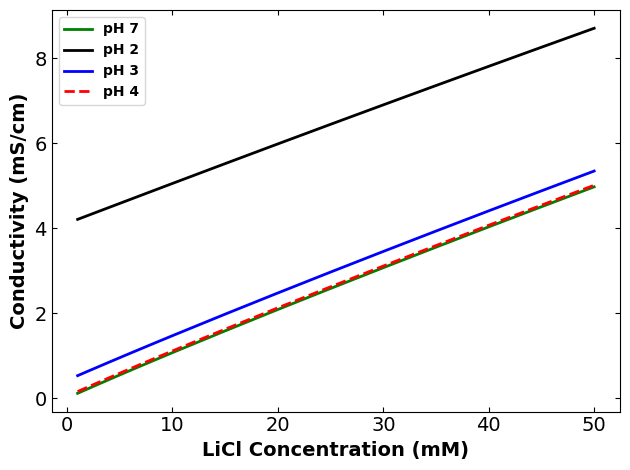

In [6]:
# plot the results
fig = plt.figure()
plt.plot(LiCl_conc, all_cond_calc_con_LiCl, "g-", linewidth=2, label="pH 7")
plt.plot(LiCl_conc, all_cond_calc_con_ph2, color="black", linestyle="-", linewidth=2, label="pH 2")
plt.plot(LiCl_conc, all_cond_calc_con_ph3, "b-", linewidth=2, label="pH 3")
plt.plot(LiCl_conc, all_cond_calc_con_ph4, color='red', linestyle='--', linewidth=2, label="pH 4")
plt.xlabel("LiCl Concentration (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(".\Li_Co\msa_licl_ph.png")
plt.show()

## Load the data for CoCl2 non-constant pH

In [7]:
# load the data
data = pd.read_csv('.\Data\CoCl2_pH3.csv')

# get the experiment time and measurements
experiment_time_raw = data['Time (s)']
experiment_time = [experiment_time_raw[i]/60 for i in range(len(experiment_time_raw))]
ICP_conc_raw = data['ICP-OES Concentration (mM)']
sample_pH_raw = data['Observed Sample pH']
permeate_temp = data['Permeate Temp']
permeate_conc_raw = data['Permeate Concentration (mM)']
permeate_cond_raw_micro = data['Permeate Cond @ Temp (uS/cm)']

# convert the conductivity from micro Siemen per cm to milli Siemen per cm
permeate_cond_raw = [permeate_cond_raw_micro[i]/1000 for i in range(len(permeate_cond_raw_micro))]

In [8]:
# convert the conductivity at recorded temperature to 25 deg. C
temp_coeff = 0.02 # per deg. C
permeate_cond_cal = [permeate_cond_raw[i] * (1 + temp_coeff * (25 - permeate_temp[i])) for i in range(len(permeate_cond_raw))]

In [9]:
# filter out the empty measurements
ICP_conc = []
sample_pH = []
exp_time_ICP_pH = []
permeate_conc = []
permeate_cond = []
for i, t in enumerate(experiment_time):
    if not pd.isna(ICP_conc_raw[i]) and not pd.isna(sample_pH_raw[i]):
        ICP_conc.append(ICP_conc_raw[i])
        sample_pH.append(sample_pH_raw[i])
        exp_time_ICP_pH.append(t)
        permeate_conc.append(permeate_conc_raw[i])
        permeate_cond.append(permeate_cond_cal[i])

print("ICP conc. in mM:\n",ICP_conc)
print("Permeate cond. in micro.S/cm:\n",permeate_cond)
print("Sample pH:\n",sample_pH)
print("Corresponding experiment time in min:\n",exp_time_ICP_pH)

# number of data points
ndata_pH = len(sample_pH)
print("The number of data points is:",ndata_pH)

# ICP measurement error
ICP_error_percent = [0.79, 1.38, 0.35, 1.04, 1.44, 0.34, 1.13, 1.16, 0.62, 1.04]
ICP_error = [(ICP_error_percent[i] / 100) * ICP_conc[i] for i in range(ndata_pH)]

ICP conc. in mM:
 [0.19278, 0.33504, 0.71337, 1.23054, 2.01759, 3.09497, 4.60706, 6.76483, 10.17519, 14.72702]
Permeate cond. in micro.S/cm:
 [0.632686736, 1.2945924479999997, 1.2215754959999998, 1.050249996, 0.968752776, 1.1052075300000002, 1.3102601600000001, 1.8467681280000001, 2.4651248359999998, 3.18054114]
Sample pH:
 [2.94, 2.66, 2.62, 2.71, 2.91, 3.07, 3.19, 3.26, 3.29, 3.27]
Corresponding experiment time in min:
 [22.009966666666667, 56.12286666666667, 80.79703333333333, 110.4561, 147.80225000000002, 196.21836666666667, 258.55469999999997, 347.13443333333333, 472.5086, 641.8151833333334]
The number of data points is: 10


In [10]:
# calculate the H+ concentration from the pH
H_conc = np.zeros(ndata_pH)
for i in range(ndata_pH):
    H_conc[i] = 1000 * (10 ** (-sample_pH[i]))

print("H+ conc. in mM:\n",H_conc)

H+ conc. in mM:
 [1.14815362 2.18776162 2.39883292 1.9498446  1.23026877 0.85113804
 0.64565423 0.54954087 0.51286138 0.5370318 ]


## Calculate the CoCl2 concentration from the permeate conductivity using the MSA model

In [11]:
# temperature in K
temp = 298.15

# diffusion coefficients at infinite dilution in m^2/s
diffusion_coeff = [Diff_Co, Diff_Cl]

# valencies
valency = [z_Co, z_Cl]

# hard sphere diameters in m
diameter = [sigma_Co, sigma_Cl]

# solvent viscosity in Pa.s
eta_msa = 0.89 * 10**(-3)

# relative permittivity
epsilon_msa = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Co_Cl = [lambda_0_Co_mol, lambda_0_Cl_mol]

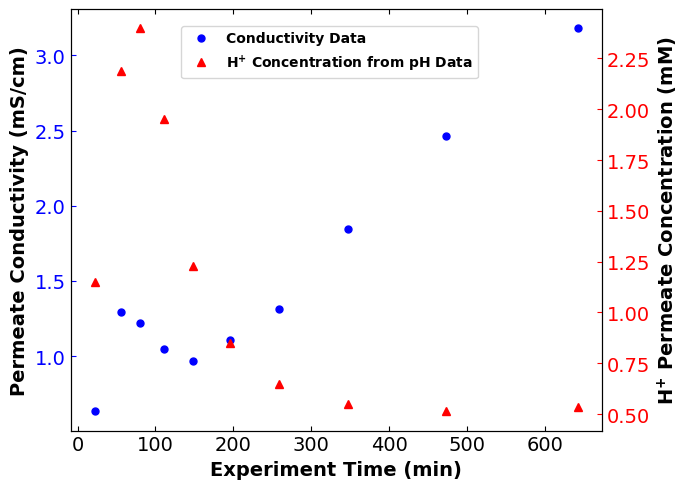

In [12]:
# make plot of the ICP Co2+ concentration and H+ sample concentration
fig, ax1 = plt.subplots(figsize=(7, 5))

ax1.plot(exp_time_ICP_pH, permeate_cond, "b.", markersize=10, label="Conductivity Data")
ax1.set_xlabel("Experiment Time (min)", fontsize=14,fontweight='bold')
ax1.set_ylabel("Permeate Conductivity (mS/cm)", fontsize=14,fontweight='bold')
ax1.tick_params(axis='x', labelsize=14, direction="in",top=True, right=True)
ax1.tick_params(axis='y', colors="blue", labelsize=14, direction="in",top=True, right=True)

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(exp_time_ICP_pH, H_conc, "r^", label="H$^\mathbf{+}$ Concentration from pH Data")
ax2.tick_params(axis='y', colors="red", labelsize=14, direction="in",top=True, right=True)
ax2.set_ylabel("H$^\mathbf{+}$ Permeate Concentration (mM)", fontsize=14,fontweight='bold')

fig.legend(prop={"weight":"bold"}, bbox_to_anchor=(0.7, 0.95), frameon=True)
plt.tight_layout()
plt.savefig(".\Li_Co\cocl2_data_paper.png")
plt.show()

## HCl conductivity contribution

In [13]:
# valencies
valency_H_Cl = [z_Cl, z_H]

# diffusion coefficients at infinite dilution in m^2/s
diff_coeff_H_Cl = [Diff_Cl, Diff_H]

# hard sphere diameters in m
diameter_H_Cl = [sigma_Cl, sigma_H]

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_H_Cl = [lambda_0_Cl_mol, lambda_0_H_mol]

# HCl concentration in mM
HCl_conc = H_conc

# calculate the bulk conductivity using the MSA transport model
HCl_cond = msa_transport(valency_H_Cl, diameter_H_Cl, diff_coeff_H_Cl, temp, eta_msa, epsilon_msa, lambda_0_H_Cl, HCl_conc)

Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Relaxation correction: [-0.00516601 -0.00516601]
Hydrodynamic correction: [-0.00900528 -0.0019867 ]
omega_bar: 1377429703786.4321
Alpha: [0.0, 1056407614413.83]
Mew: [0.5 0.5]
Transport number: [0.17914132 0.82085868]
Omega: [4.93509152e+11 2.26135026e+12]
ksi: [[ 2.1406039  -1.        ]
 [ 0.46715789  1.        ]]


### H+

In [14]:
# valencies
valency_H = [z_H]

# diffusion coefficients at infinite dilution in m^2/s
diff_coeff_H = [Diff_H]

# hard sphere diameters in m
diameter_H = [sigma_H]

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_H = [lambda_0_H_mol]

# calculate the bulk conductivity using the MSA transport model
H_cond = cd.msa_transport(valency_H, diameter_H, diff_coeff_H, temp, eta_msa, epsilon_msa, lambda_0_H, H_conc)

Relaxation correction: [-0.]
Hydrodynamic correction: [-0.00141471]
omega_bar: 2261350255127.474
Alpha: [0.0]
Mew: [1.]
Transport number: [1.]
Omega: [2.26135026e+12]
ksi: [[1.]]


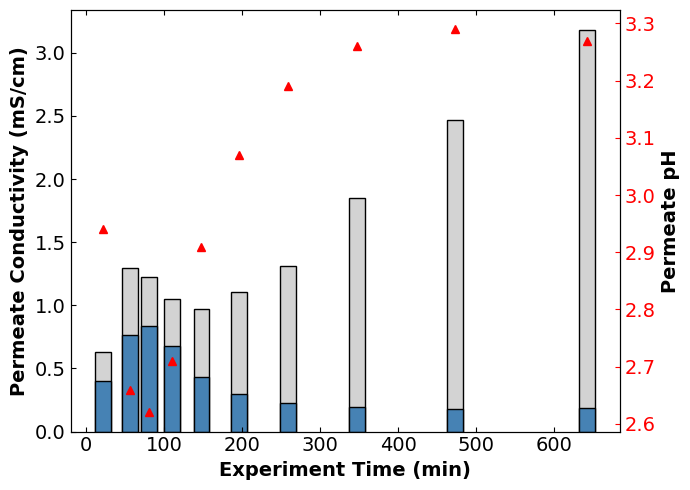

In [15]:
# making plot comparison of the bulk permeate and H+ conductivity
fig, ax1 = plt.subplots(figsize=(7, 5))

ax1.bar(exp_time_ICP_pH, permeate_cond, color='lightgray', edgecolor='black', width=20, label='Conductivity Data')
ax1.bar(exp_time_ICP_pH, H_cond, color='steelblue', edgecolor='black', width=20, label='MSA H$^\mathbf{+}$ Conductivity Contribution')
ax1.set_xlabel("Experiment Time (min)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Permeate Conductivity (mS/cm)", fontsize=14,fontweight='bold')
ax1.tick_params(axis='x', labelsize=14, direction="in",top=True, right=True)
ax1.tick_params(axis='y', labelsize=14, direction="in",top=True, right=True)

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(exp_time_ICP_pH, sample_pH, "r^", label="pH Data")
ax2.tick_params(axis='y', colors='red', labelsize=14, direction="in",top=True, right=True)
ax2.set_ylabel("Permeate pH", fontsize=14, fontweight='bold')

# fig.legend(prop={"weight":"bold"}, bbox_to_anchor=(0.41, 0.9))
plt.tight_layout()
plt.savefig(".\Li_Co\h_co_cl_conductivity_paper.png")
plt.show()

## MSA Model Co2+ conductivity and concentration

In [16]:
# CoCl2 and HCl constants
diff_coeff_Co_Cl_H = [Diff_Co, Diff_Cl, Diff_H] # diffusion coefficients of Ca, Na, and Cl, respectively
valency_Co_Cl_H = [z_Co, z_Cl, z_H] # valencies of Ca, Na, and Cl, respectively
diameter_Co_Cl_H = [sigma_Co, sigma_Cl, sigma_H] # effective ionic diameters of Ca, Na, and Cl, respectively
lambda_0_Co_Cl_H = [lambda_0_Co_mol, lambda_0_Cl_mol, lambda_0_H_mol]

In [17]:
# Mean spherical approximation (MSA) transport model for multi-salt specific conductivity
def msa_transport_single(valency, diameters, diff_coeff, temp, eta, epsilon, lambda_0,
                  cat_1_conc, an_conc, cat_2_conc):
    """Calculates the specific conductivity of single-salt, two-salt, and three-salt solutions

    Argument:
        valency: list, valency of ions in decreasing order with hydrogen ion as the last entry
        diameters: list, corresponding hard sphere diameter of the ions in m
        diff_coeff: list, corresponding diffusion coefficient of the ions at infinite dilution in m^2/s
        temp: int or float, temperature in K
        eta: int or float, viscosity in Pa.s
        epsilon: int or float, relative permittivity
        lambda_0: list, corresponding limiting molar conductivity of the ions in S.m^2/mol
        cat_1_conc = Pandas series or list, concentration of cation 1 in mM
        an_conc = Pandas series or list, concentration of the common anion in mM
        cat_2_conc = Pandas series or list, concentration of cation 2 in mM

    Returns:
        all_cond_calc_con: specific conductivity of the salt solution in milli.S/cm"""

    # constants
    Avogadros_num = 6.022 * 10 ** 23  # Avogadro's constant
    k_B = 1.381 * 10 ** (-23)  # Boltzmann constant in J/K
    charge = 1.602 * 10 ** (-19)  # elementary charge in C
    epsilon_0 = 8.854 * 10 ** (-12)  # permittivity of free space in F/m
    Faraday = 96500  # Faraday's constant in C/mol

    # number of species
    n_species = len(valency)

    # species charge
    ion_charge = [valency[i] * charge for i in range(len(valency))]

    # valency of cations
    valency_cation_1 = valency[0]
    valency_cation_2 = valency[2]

    # evaluating the number density of individual species
    n_cat_1 = cat_1_conc * Avogadros_num
    n_cat_2 = cat_2_conc * Avogadros_num
    n_an = an_conc * Avogadros_num

    # calculate the bulk conductivity of the salt solution
    all_cond_calc = 0
    
    # number density of species
    number_density = [n_cat_1, n_an, n_cat_2]

    # calculate the species ionic mobility (omega) and the relative ionic strength (mew)
    omega = np.zeros(n_species)
    mew = np.zeros(n_species)
    for a in range(n_species):
        omega[a] = diff_coeff[a] / (k_B * temp)
        mew[a] = number_density[a] * ion_charge[a] ** 2 / sum(
            number_density[j] * ion_charge[j] ** 2 for j in range(n_species))

    # calculate the Debye length from equation (5)
    kappa = math.sqrt(
        sum(number_density[l] * ion_charge[l] ** 2 / (epsilon * epsilon_0 * k_B * temp) for l in range(n_species)))

    # calculate the mean mobility from equation (7)
    omega_bar = sum(mew[j] * omega[j] for j in range(n_species))

    # calculate the transport number of all species from equation (8)
    transport_num = np.zeros(n_species)
    for j in range(n_species):
        transport_num[j] = mew[j] * omega[j] / omega_bar
    # print("The transport number is:",transport_num)

    # calculate the value of alpha from the function containing alpha
    alpha_scaled = np.zeros(n_species)
    def func_alpha(alpha_scaled):
        """
        Evaluates residuals of equation 12

        Arguments:
            alpha_scaled = alpha/omega_bar

        Returns:
            residual of equation 12
        """
        return ((alpha_scaled) * sum(
            transport_num[k] / ((omega[k] / omega_bar) ** 2 - (alpha_scaled) ** 2) for k in range(n_species)))

    # since alpha is scaled by omega_bar, omega need to be scaled by same factor
    omega_scaled = np.zeros(n_species)
    for k in range(n_species):
        omega_scaled[k] = omega[k] / omega_bar
        
    # updating the values of alpha_scaled
    for p in range(n_species):
        if p == 0:
            alpha_scaled[p] = bisect(func_alpha, 0, 0.991 * omega_scaled[p])
        else:
            alpha_scaled[p] = bisect(func_alpha, 1.0001 * omega_scaled[p - 1], 0.9991 * omega_scaled[p])

    # re-scaling alpha_scaled back to alpha
    alphas = [alpha_scaled[p] * omega_bar for p in range(n_species)]

    # calculate the q and N values of all species
    q = np.zeros(n_species)
    N = np.zeros(n_species)
    for p in range(n_species):
        q[p] = sum(omega_bar * transport_num[r] / (omega[r] + alphas[p]) for r in range(n_species))
        N[p] = math.sqrt(1 / sum(
            transport_num[r] * omega[r] ** 2 / (omega[r] ** 2 - alphas[p] ** 2) ** 2 for r in range(n_species)))

    # ksi matrix
    ksi = np.zeros((n_species, n_species))

    # calculate the hydrodynamic correction
    delta_vel_divide_vel = np.zeros(n_species)
    for i in range(n_species):
        # update the hydrodynamic correction; equation (16) divide equation (2)
        prefactor = -(Faraday ** 2) * np.abs(valency[i]) / (
                    12 * math.pi * epsilon_0 * epsilon * eta * k_B * temp * Avogadros_num * lambda_0[i])
        delta_vel_divide_vel[i] = prefactor * sum(number_density[j] * ion_charge[j] ** 2 *
                                                  ((np.exp(kappa * (diameters[i] - 0.5 * (
                                                              diameters[i] + diameters[j]))) / (
                                                                kappa * (1 + kappa * diameters[i]))) +
                                                   (np.exp(kappa * (diameters[j] - 0.5 * (
                                                               diameters[i] + diameters[j]))) / (
                                                                kappa * (1 + kappa * diameters[j]))))
                                                  for j in range(n_species))

        # update the ksi matrix
        for p in range(n_species):
            ksi[i][p] = N[p] * omega[i] / (omega[i] ** 2 - alphas[p] ** 2)

    # calculate the conductivity of the species
    cond_species = np.zeros(n_species)

    # calculate the relaxation correction
    delta_k_divide_k = np.zeros(n_species)
    for i in range(n_species):
        delta_k_divide_k_sum = 0.0
        for p in range(n_species):
            inner_delta_k_divide_k_sum = 0.0
            for j in range(n_species):
                for a in range(n_species):
                    # calculate the average diameter
                    sigma_aj = 0.5 * (diameters[a] + diameters[j])

                    # first fraction of summation term
                    term1 = transport_num[j] * ksi[j][p] * mew[a] * (
                            ion_charge[a] * omega[a] - ion_charge[j] * omega[j]) / (
                                    ion_charge[a] * ion_charge[j] * (omega[a] + omega[j]))

                    # second fraction of summation term
                    term2 = math.sinh(kappa * math.sqrt(q[p]) * sigma_aj) / (kappa * math.sqrt(q[p]) * sigma_aj)

                    # evaluate the integral term
                    integral_prefactor = - (charge ** 2 * valency[a] * valency[j]) / (
                                8 * math.pi * epsilon_0 * epsilon * k_B * temp)

                    integral_term1 = np.exp(kappa * diameters[j]) / (1 + kappa * diameters[j])
                    integral_term2 = np.exp(kappa * diameters[a]) / (1 + kappa * diameters[a])

                    integral_exp_term = np.exp(-kappa * (1 + np.sqrt(q[p])) * sigma_aj) / (
                                kappa * (1 + np.sqrt(q[p])))

                    integral = integral_prefactor * (integral_term1 + integral_term2) * integral_exp_term

                    inner_delta_k_divide_k_sum += term1 * term2 * integral

            delta_k_divide_k_sum += ksi[i][p] * inner_delta_k_divide_k_sum

        # update the relaxation correction
        delta_k_divide_k[i] = -(kappa ** 2) * ion_charge[i] * delta_k_divide_k_sum / 3

        # update the conductivity of the species
        cond_species[i] = (charge ** 2) * number_density[i] * diff_coeff[i] * (valency[i] ** 2) * (
                1 + delta_vel_divide_vel[i]) * (1 + delta_k_divide_k[i]) / (k_B * temp)

    # calculate the bulk conductivity of the solution
    all_cond_calc += sum(cond_species)

    # convert the calculated conductivity from S/m to milli.S/cm
    cond_calc_con = all_cond_calc * 10 ** 3 / 100
    
    return cond_calc_con

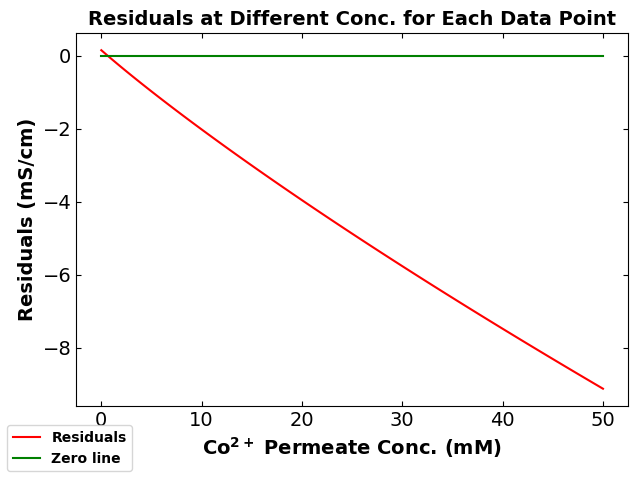

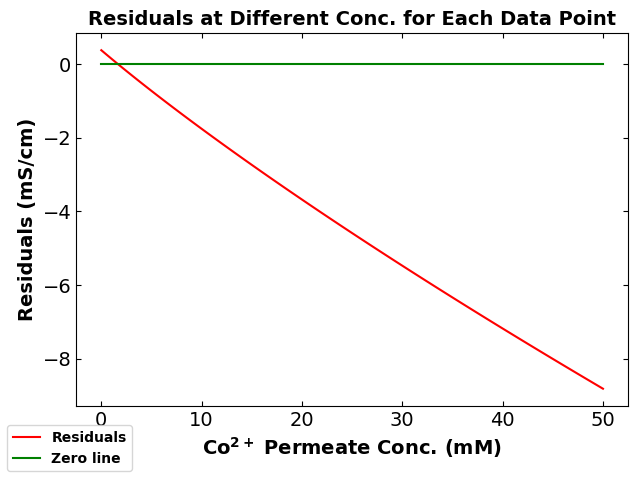

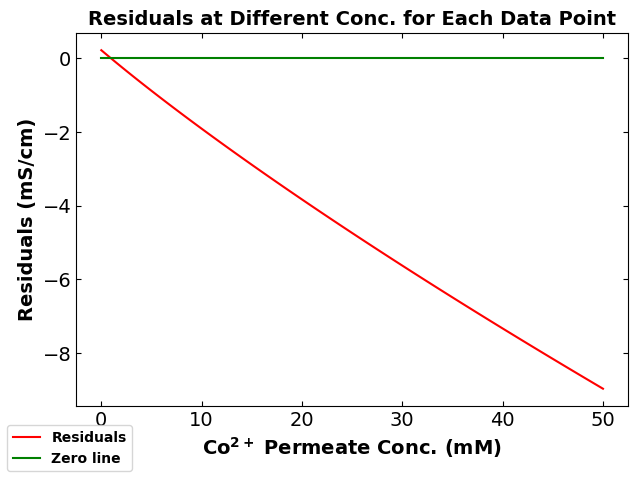

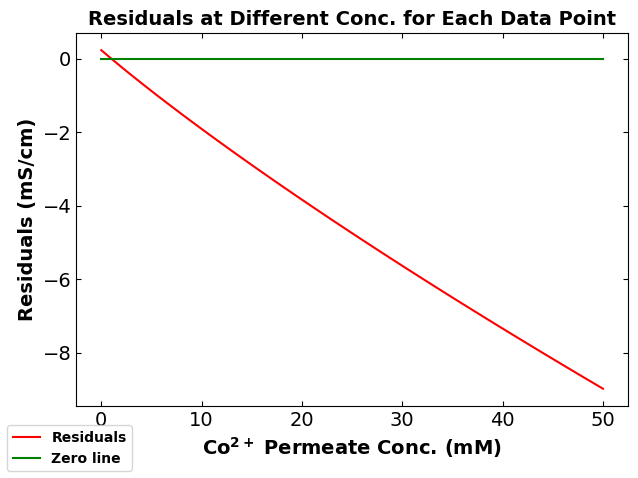

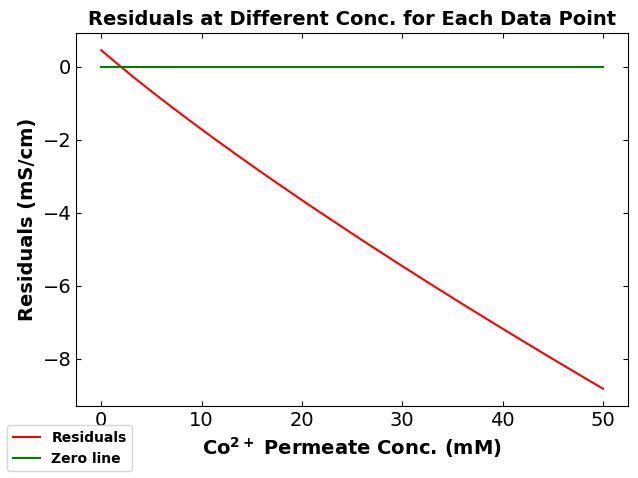

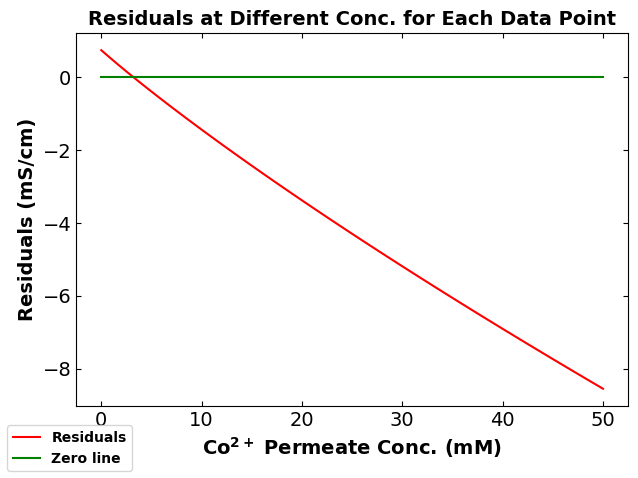

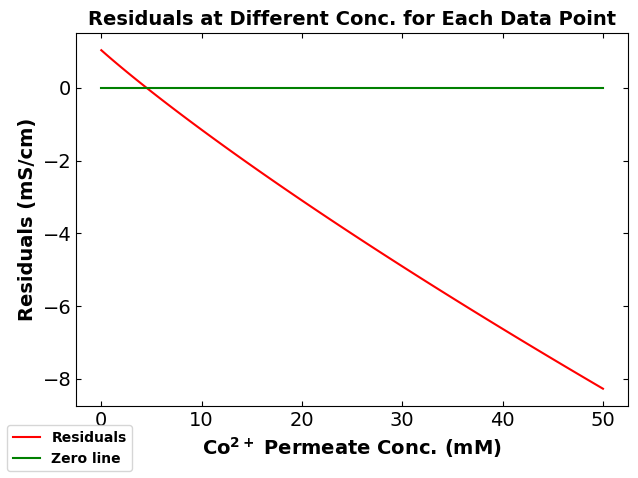

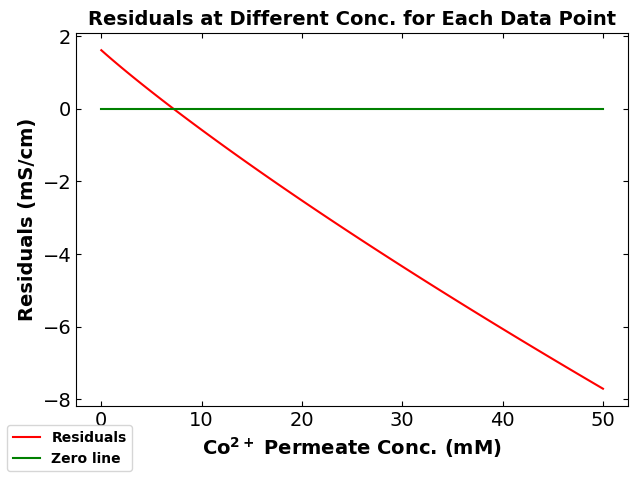

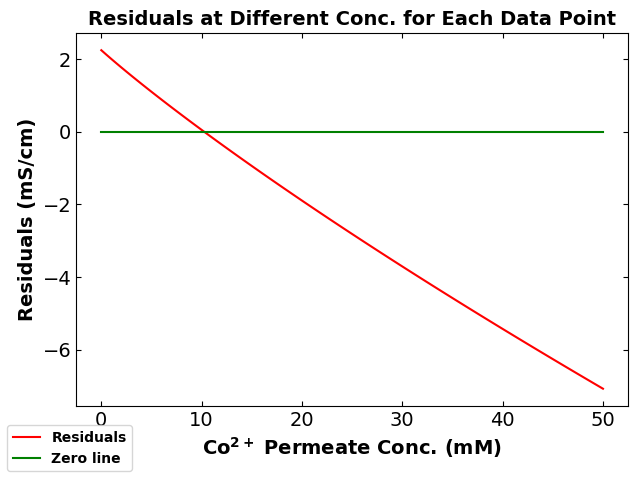

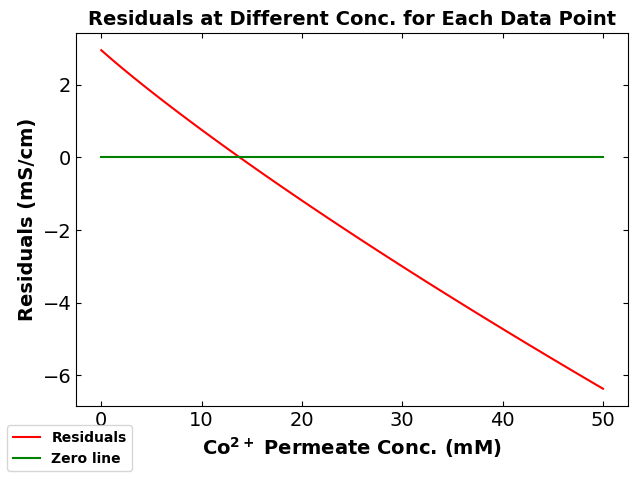

In [18]:
CoCl2_conc = np.zeros(ndata_pH)
for i in range(ndata_pH):
    
    # get the permeate conductivity data
    permeate_cond_single = permeate_cond[i]

    # get the hydrogen ion concentration data
    H_conc_single = HCl_conc[i]

    # list of cobalt ion concentration in mM
    Co_conc_list = np.linspace(0.001, 50, 100)

    # list of conductivity residuals
    zero_cond_residuals = np.zeros(len(Co_conc_list))
    calc_cond_residuals = []
    for j, Co_conc_single in enumerate(Co_conc_list):
        
        # calculate the chloride ion concentration
        Cl_conc_single = 1 * H_conc_single + 2 * Co_conc_single
        
        # calculate the bulk conductivity using the MSA transport model
        msa_cond_single = msa_transport_single(valency_Co_Cl_H, diameter_Co_Cl_H, diff_coeff_Co_Cl_H, temp, eta_msa, epsilon_msa, lambda_0_Co_Cl_H, 
                                    Co_conc_single, Cl_conc_single, H_conc_single)
    
        # calculate the residuals between the measured and predicted salt conductivity
        calc_residuals = permeate_cond_single - msa_cond_single
            
        calc_cond_residuals.append(calc_residuals)

    # get the first negative residual and its index
    first_neg_cond = next((x for x in calc_cond_residuals if x < 0), None)
    index_first_neg = calc_cond_residuals.index(first_neg_cond)

    # get the concentration that corresponds to the first negative residual
    conc_first_neg = Co_conc_list[index_first_neg]

    # get the previous positive residual and its index
    prev_cond_value = calc_cond_residuals[index_first_neg-1]

    # get the concentration that corresponds to the previous positive residual
    prev_conc_value = Co_conc_list[index_first_neg-1]

    # calculate the concentration that produce a residua of zero
    CoCl2_conc[i] = prev_conc_value + (prev_cond_value / (prev_cond_value - first_neg_cond)) * (conc_first_neg - prev_conc_value)

    # make plot of the ICP Co2+ concentration and H+ sample concentration
    fig, ax1 = plt.subplots()
    
    ax1.plot(Co_conc_list, calc_cond_residuals, color="red", label="Residuals")
    ax1.plot(Co_conc_list, zero_cond_residuals, color="green", label="Zero line")
    ax1.set_xlabel("Co$^\mathbf{2+}$ Permeate Conc. (mM)", fontsize=14,fontweight='bold')
    ax1.set_ylabel("Residuals (mS/cm)", fontsize=14,fontweight='bold')
    ax1.tick_params(axis='x', labelsize=14, direction="in",top=True, right=True)
    ax1.tick_params(axis='y', labelsize=14, direction="in",top=True, right=True)
    plt.title("Residuals at Different Conc. for Each Data Point", fontsize=14,fontweight='bold')
    fig.legend(prop={"weight":"bold"}, loc="lower left")
    plt.tight_layout()
    plt.show()

In [19]:
print(CoCl2_conc)

[ 0.63197908  1.66433897  0.95702753  1.01177842  1.94122853  3.22590221
  4.52512587  7.20567465 10.26739659 13.80627393]


### Plot the residuals at the respective concentration

In [20]:
predicted_cond = []
for i, Co_conc in enumerate(CoCl2_conc):
    
    # get the hydrogen ion concentration data
    H_conc_single = HCl_conc[i]
        
    # calculate the chloride ion concentration
    Cl_conc_single = 1 * H_conc_single + 2 * Co_conc
    
    # calculate the bulk conductivity using the MSA transport model
    predicted_cond.append(msa_transport_single(valency_Co_Cl_H, diameter_Co_Cl_H, diff_coeff_Co_Cl_H, temp, eta_msa, epsilon_msa, lambda_0_Co_Cl_H, 
                                Co_conc, Cl_conc_single, H_conc_single))

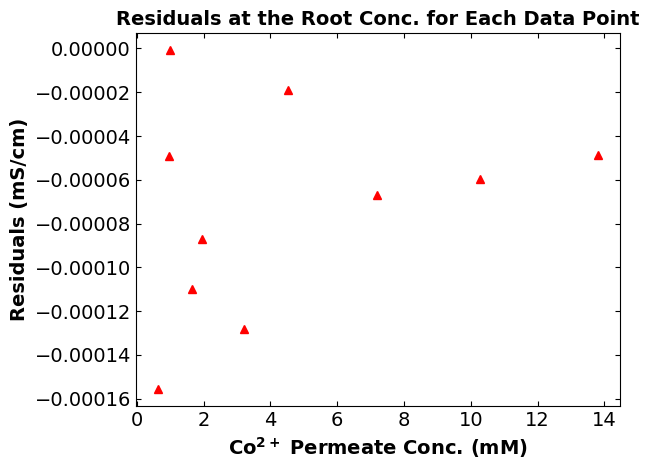

In [21]:
# residuals of the msa conductivity prediction
cond_res = [permeate_cond[i] - predicted_cond[i] for i in range(ndata_pH)]

# plot the residuals
fig, ax1 = plt.subplots()

ax1.plot(CoCl2_conc, cond_res, "^", color="red", label="Probe-MSA")
ax1.set_xlabel("Co$^\mathbf{2+}$ Permeate Conc. (mM)", fontsize=14,fontweight='bold')
ax1.set_ylabel("Residuals (mS/cm)", fontsize=14,fontweight='bold')
ax1.tick_params(axis='x', labelsize=14, direction="in",top=True, right=True)
ax1.tick_params(axis='y', labelsize=14, direction="in",top=True, right=True)
plt.title("Residuals at the Root Conc. for Each Data Point", fontsize=14,fontweight='bold')
plt.tight_layout()
# plt.savefig(".\Li_Co\msa_co_cond_resid_conc.png")
plt.show()

## Shedlovsky model Co2+ conductivity and concentration

In [22]:
# constants
eta_shed = 8.9*10**(-3) # poise
lambda_0_HCl = 426.15 # cm^2.Siemen.equiv^(-1)
lambda_0_H = 349.8 # cm^2.Siemen.equiv^(-1)
lambda_0_Cl = 76.35 # cm^2.Siemen.equiv^(-1)
a_HCl = 4.4*10**(-8) # cm
lambda_0_CoCl2 = 131.35 # cm^2.Siemen.equiv^(-1)
lambda_0_Co = 55 # cm^2.Siemen.equiv^(-1)
a_CoCl2 = 4.5*10**(-8) # cm
a_H_Co = (a_HCl + a_CoCl2)/2

In [23]:
# Shedlovsky model for single concentration
def _shedlovsky(conc, temp, epsilon, eta, lambda_0, a, z_1, z_2, lambda_0_cation, lambda_0_anion):
    """
    Calculates equivalent conductivity using equation (7.36) in reference

    Arguments:
        conc: float or int, salt concentration in M
        temp: int or float, temperature in K
        epsilon: int or float, dielectric constant
        eta: int or float, viscosity of the salt solution in poise
        lambda_0: int or float, limiting equivalent conductivity of the salt in cm^2.S/equiv
        a: int or float, distance within which no other ions can penetrate in cm
        z_1: int, valency of the cation
        z_2: int, valency of the anion
        lambda_0_cation: int or float, limiting equivalent conductivity of the cation in cm^2.S/equiv
        lambda_0_anion: int or float, limiting equivalent conductivity of the anion in cm^2.S/equiv

    Returns:
        equiv_cond: equivalent conductivity of the salt in cm^2.S/equiv
    """
    # calculate the B and q constants
    B = 50.29 * (10 ** 8) * (epsilon * temp) ** (-0.5)
    q = np.abs(z_1 * z_2) * (lambda_0_cation + lambda_0_anion) / (
                (np.abs(z_1) + np.abs(z_2)) * (np.abs(z_2) * lambda_0_cation + np.abs(z_1) * lambda_0_anion))

    # calculate the relaxation correction, B1, and the hydrodynamic correction, B2
    B_1 = 2.801 * 10 ** 6 * np.abs(z_1 * z_2) * q / ((epsilon * temp) ** (3 / 2) * (1 + math.sqrt(q)))
    B_2 = 41.25 * (np.abs(z_1) + np.abs(z_2)) / (eta * (epsilon * temp) ** (1 / 2))

    # ion concentration
    cation_conc = conc
    Cl_conc = np.abs(z_1) * conc

    # calculate the ionic strength
    conc_all = [cation_conc, Cl_conc]
    z = [z_1, z_2]
    I = 1 / 2 * (sum(conc_all[j] * z[j] ** 2 for j in range(len(conc_all))))

    # calculate the salt equivalent conductivity
    equiv_cond = lambda_0 - ((B_1 * lambda_0 + B_2) * math.sqrt(I) / (1 + a * B * math.sqrt(I)))

    return equiv_cond


# variant Shedlovsky model for predicting electrolyte specific conductivity
def variant_shedlovsky(conc, temp, epsilon, eta, lambda_0, a, z_1, z_2, lambda_0_cation, lambda_0_anion):
    """
    Calculates specific conductivity from equivalent conductivity

    Arguments:
        conc: float or int, salt concentration in M
        temp: int or float, temperature in K
        epsilon: int or float, dielectric constant
        eta: int or float, viscosity of the salt solution in poise
        lambda_0: int or float, limiting equivalent conductivity of the salt in cm^2.S/equiv
        a: int or float, distance within which no other ions can penetrate in cm
        z_1: int, valency of the cation
        z_2: int, valency of the anion
        lambda_0_cation: int or float, limiting equivalent conductivity of the cation in cm^2.S/equiv
        lambda_0_anion: int or float, limiting equivalent conductivity of the anion in cm^2.S/equiv

    Returns:
        specific_cond_calc: specific conductivity of the salt in milli S/cm
    """

    # calculate the salt equivalent conductivity
    equiv_cond = _shedlovsky(conc, temp, epsilon, eta, lambda_0, a, z_1, z_2, lambda_0_cation, lambda_0_anion)

    # cation concentration
    cation_conc = conc

    # convert the cation concentrations from M to equivalent per litre
    equiv_conc = cation_conc * np.abs(z_1)

    # calculate the salt specific conductivity in Siemen per cm
    specific_cond = (equiv_conc / 1000) * equiv_cond

    # specific conductivity in milli Siemen per cm
    specific_cond_calc = specific_cond * 10 ** 3

    return specific_cond_calc

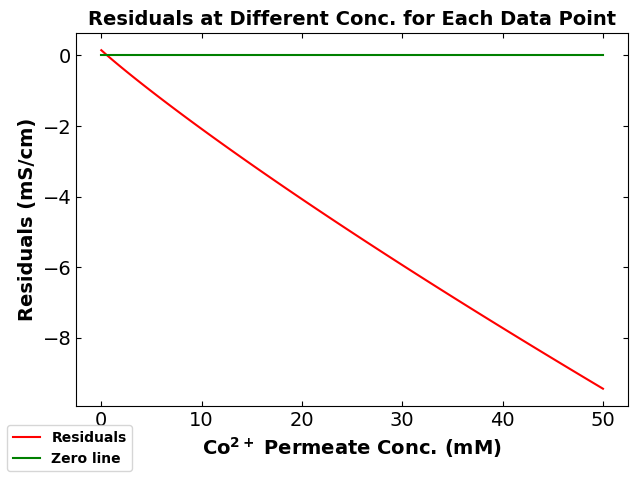

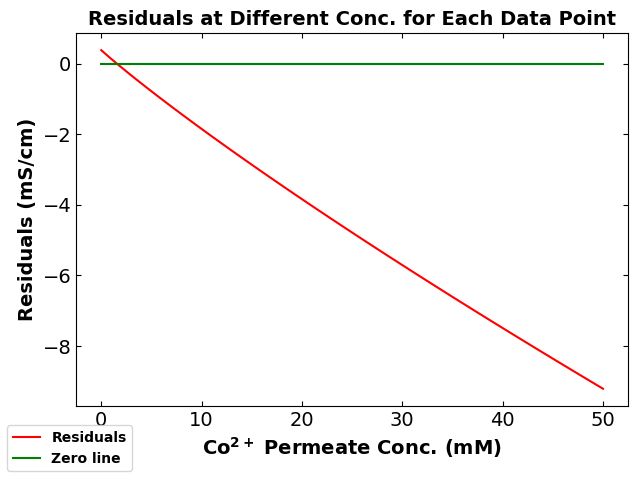

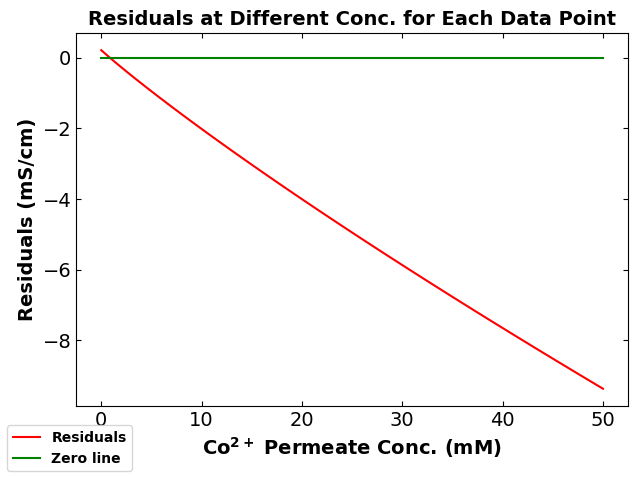

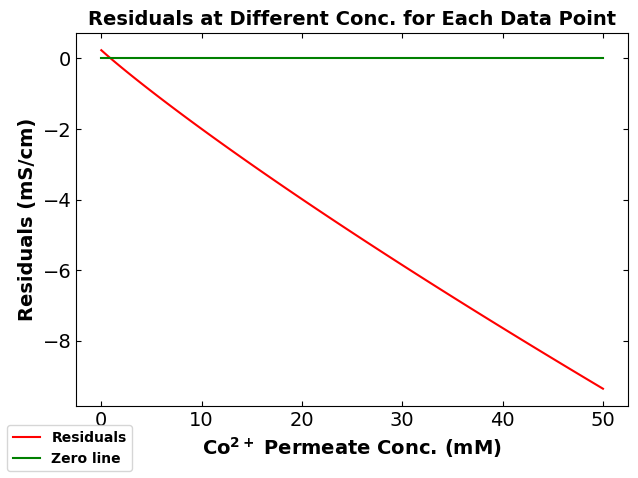

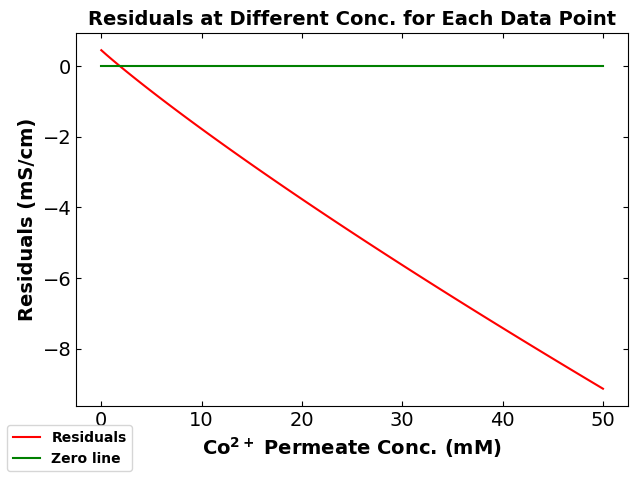

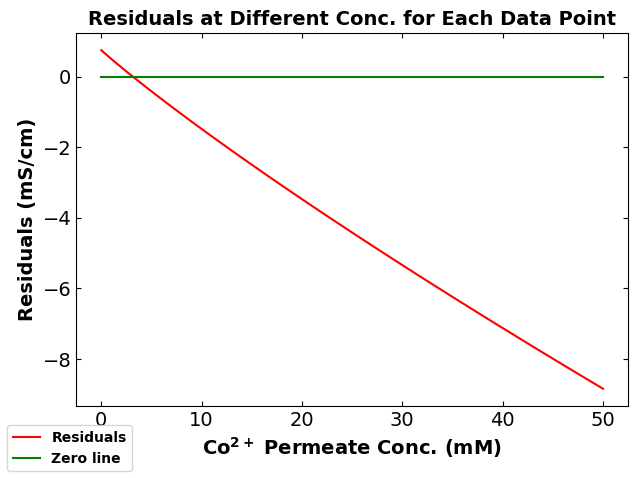

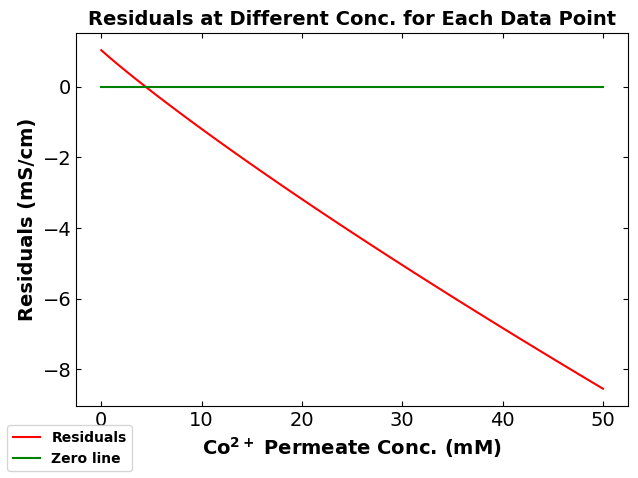

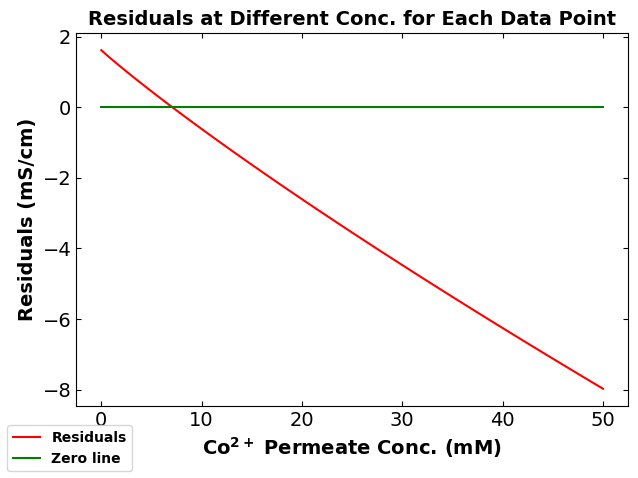

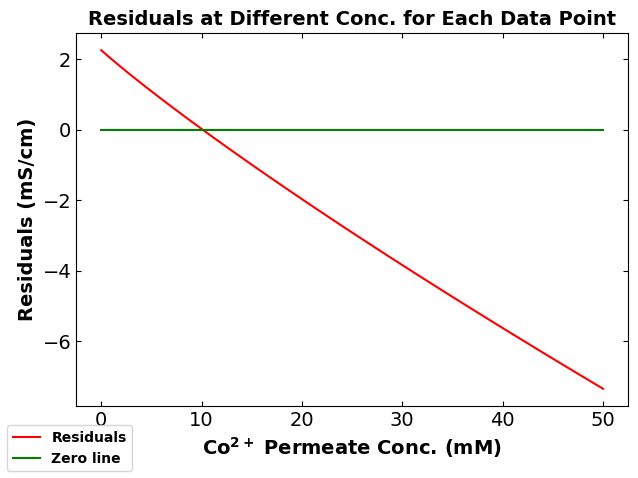

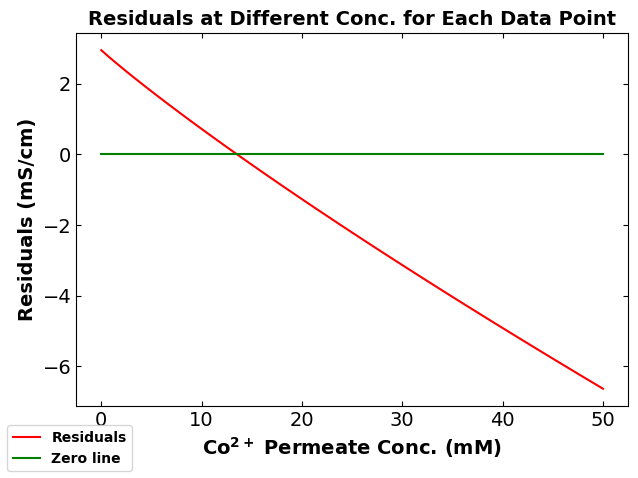

In [24]:
CoCl2_conc_shed = np.zeros(ndata_pH)
for i in range(ndata_pH):
    
    # get the permeate conductivity data
    permeate_cond_single = permeate_cond[i]

    # HCl conc
    HCl_conc_single = HCl_conc[i] * 10**(-3)

    # list of cobalt ion concentration in mM
    Co_conc_list = np.linspace(0.001, 50, 100)

    # list of conductivity residuals
    zero_cond_residuals = np.zeros(len(Co_conc_list))
    calc_cond_residuals = []
    for j, Co_conc_single in enumerate(Co_conc_list):
        
        # HCl specific conductivity in milli Siemen per cm
        specific_cond_calc_H = variant_shedlovsky(HCl_conc_single, T, epsilon, eta_shed, lambda_0_HCl, a_H_Co, z_H, z_Cl, lambda_0_H, lambda_0_Cl)

        # CoCl2 specific conductivity in milli Siemen per cm
        specific_cond_calc_Co = variant_shedlovsky(Co_conc_single * 10**(-3), T, epsilon, eta_shed, lambda_0_CoCl2, a_H_Co, z_Co, z_Cl, 
                                                   lambda_0_Co, lambda_0_Cl)
        
        # calculate the bulk conductivity using the Shedlovsky model
        bulk_cond_single = specific_cond_calc_H + specific_cond_calc_Co
    
        # calculate the residuals between the measured and predicted conductivity
        calc_residuals = permeate_cond_single - bulk_cond_single
            
        calc_cond_residuals.append(calc_residuals)

    # get the first negative residual and its index
    first_neg_cond = next((x for x in calc_cond_residuals if x < 0), None)
    index_first_neg = calc_cond_residuals.index(first_neg_cond)

    # get the concentration that corresponds to the first negative residual
    conc_first_neg = Co_conc_list[index_first_neg]

    # get the previous positive residual and its index
    prev_cond_value = calc_cond_residuals[index_first_neg-1]

    # get the concentration that corresponds to the previous positive residual
    prev_conc_value = Co_conc_list[index_first_neg-1]

    # calculate the concentration that produce a residua of zero
    CoCl2_conc_shed[i] = prev_conc_value + (prev_cond_value / (prev_cond_value - first_neg_cond)) * (conc_first_neg - prev_conc_value)

    # make plot of the ICP Co2+ concentration and H+ sample concentration
    fig, ax1 = plt.subplots()
    
    ax1.plot(Co_conc_list, calc_cond_residuals, color="red", label="Residuals")
    ax1.plot(Co_conc_list, zero_cond_residuals, color="green", label="Zero line")
    ax1.set_xlabel("Co$^\mathbf{2+}$ Permeate Conc. (mM)", fontsize=14,fontweight='bold')
    ax1.set_ylabel("Residuals (mS/cm)", fontsize=14,fontweight='bold')
    ax1.tick_params(axis='x', labelsize=14, direction="in",top=True, right=True)
    ax1.tick_params(axis='y', labelsize=14, direction="in",top=True, right=True)
    plt.title("Residuals at Different Conc. for Each Data Point", fontsize=14,fontweight='bold')
    fig.legend(prop={"weight":"bold"}, loc="lower left")
    plt.tight_layout()
    plt.show()

In [25]:
print(CoCl2_conc_shed)

[ 0.59492839  1.54109943  0.87116581  0.9345062   1.85359355  3.13158794
  4.42722641  7.07424416 10.08696661 13.5479383 ]


## Compare the calculated concentration with ICP-OES data

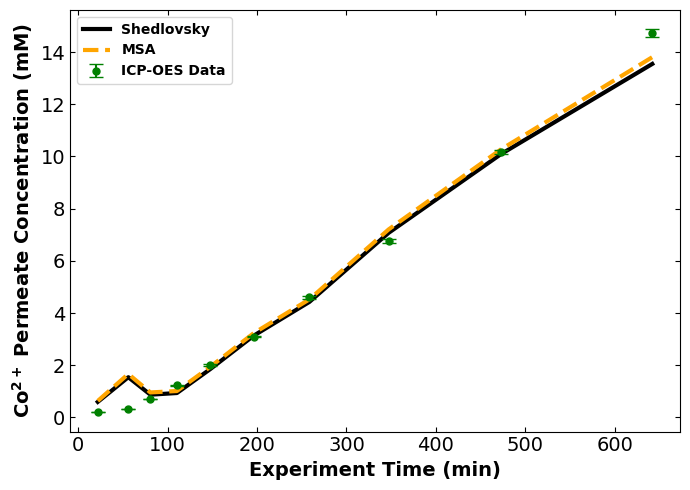

In [26]:
fig = plt.figure(figsize=(7, 5))
plt.plot(exp_time_ICP_pH, CoCl2_conc_shed, "-", color="black", linewidth=3, label="Shedlovsky")
plt.plot(exp_time_ICP_pH, CoCl2_conc, "--", color="orange", linewidth=3, label="MSA")
plt.errorbar(
    exp_time_ICP_pH, ICP_conc, yerr=ICP_error, fmt='.', ecolor='green', capsize=5, markersize=10, markerfacecolor='green',
    markeredgecolor='green', label='ICP-OES Data')
plt.xlabel("Experiment Time (min)", fontsize=14,fontweight='bold')
plt.ylabel("Co$^\mathbf{2+}$ Permeate Concentration (mM)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(".\Li_Co\msa_icp_co_conc_paper.png")
plt.show()

9.425280056597815


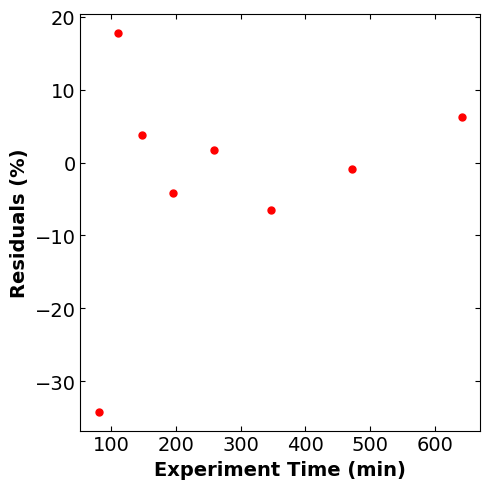

In [27]:
# residuals of the MSA model
e = [ICP_conc[i] - CoCl2_conc[i] for i in range(ndata_pH)]

# residuals percent
residuals_percent = [100*e[i]/ICP_conc[i] for i in range(ndata_pH)]

# absolute value of residuals percent
residuals_percent_abs = [np.abs(residuals_percent[i]) for i in range(ndata_pH)]
print(np.mean(residuals_percent_abs[2:]))

# plot the percent residuals
fig = plt.figure(figsize=(5, 5))

plt.plot(exp_time_ICP_pH[2:], residuals_percent[2:], ".", color="red", markersize=10)
plt.xlabel("Experiment Time (min)", fontsize=14, fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.tight_layout()
plt.savefig(".\Li_Co\msa_icp_co_conc_resid_paper.png")
plt.show()

# Calibration Curve

## HCl

In [28]:
# loading HCl specific conductivity data
specific_data = pd.read_csv("./Data/HCl.csv")
molar_conc_specific_H = specific_data["Conc"]
specific_cond_calibrated_H_raw = specific_data["Cond"]

# number of data points
ndata_H = len(specific_cond_calibrated_H_raw)

# convert the conductivity from micro Siemen per cm to milli Siemen per cm
specific_cond_calibrated_H = [specific_cond_calibrated_H_raw[i]/1000 for i in range(ndata_H)]

# measurement error
error_H = (-0.00007 * molar_conc_specific_H + 0.0102) * specific_cond_calibrated_H

### Variant Shedlovsky Model

In [29]:
# concentration in M
conc_H = [molar_conc_specific_H[i]*10**(-3) for i in range(ndata_H)]

# HCl specific conductivity in micro Siemen per cm
specific_cond_calc_H = cd.variant_shedlovsky(conc_H, T, epsilon, eta_shed, lambda_0_HCl, a_HCl, z_H, z_Cl, lambda_0_H, lambda_0_Cl)

# residuals
e_HCl_shed = [specific_cond_calibrated_H[i] - specific_cond_calc_H[i] for i in range(ndata_H)]
print("Residuals:",e_HCl_shed)

# residuals percent or fraction
residuals_percent_HCl_shed = [100*e_HCl_shed[i]/specific_cond_calibrated_H[i] for i in range(ndata_H)]
print("\nPercent errors:",residuals_percent_HCl_shed)

# absolute value of relative error
residuals_percent_HCl_abs_shed = [np.abs(residuals_percent_HCl_shed[i]) for i in range(ndata_H)]
print("\nThe mean absolute percent error of HCl is:", np.mean(residuals_percent_HCl_abs_shed))

# calculate the mean absolute error
e_HCl_abs_shed = [np.abs(e_HCl_shed[i]) for i in range(ndata_H)]
print("\nThe mean absolute error of HCl is:",np.mean(e_HCl_abs_shed))

# calculate the mean squared error
sq_residuals_HCl_shed = [e_HCl_shed[i]**2 for i in range(ndata_H)]
print("\nThe mean squared error of HCl is:",np.mean(sq_residuals_HCl_shed))

Residuals: [-0.0026788698606269937, -0.01869045254593582, -0.09564887217614593, -0.19963270264414712, -0.562562050730552, 1.0272986999151783]

Percent errors: [-6.734212822088972, -4.641630254534934, -4.820282829015065, -5.088128014378669, -2.8987584414415006, 2.555088046349247]

The mean absolute percent error of HCl is: 4.4563500679680645

The mean absolute error of HCl is: 0.31775194131209766

The mean squared error of HCl is: 0.23686285197387616


### MSA model

In [30]:
# constants
diffusion_coeff_HCl = [Diff_Cl, Diff_H] # diffusion coefficients of Na, and Cl, respectively
valency_HCl = [z_Cl, z_H] # valencies of Na, and Cl, respectively
diameter_HCl = [sigma_Cl, sigma_H] # effective ionic diameters of Na, and Cl, respectively
lambda_0_H_Cl = [lambda_0_Cl_mol, lambda_0_H_mol]

# calculated conductivity in uS/cm
cond_HCl = msa_transport(valency_HCl, diameter_HCl, diffusion_coeff_HCl, T, eta, epsilon, lambda_0_H_Cl, molar_conc_specific_H)

# residuals
e_HCl = [specific_cond_calibrated_H[i] - cond_HCl[i] for i in range(ndata_H)]
print("\nResiduals:",e_HCl)

# residuals percent or fraction
residuals_percent_HCl = [100*e_HCl[i]/specific_cond_calibrated_H[i] for i in range(ndata_H)]
print("\nPercent errors:",residuals_percent_HCl)

# absolute value of relative error
residuals_percent_HCl_abs = [np.abs(residuals_percent_HCl[i]) for i in range(ndata_H)]
print("\nThe mean absolute percent error of HCl is:", np.mean(residuals_percent_HCl_abs))

# calculate the mean absolute error
e_HCl_abs = [np.abs(e_HCl[i]) for i in range(ndata_H)]
print("\nThe mean absolute error of HCl is:",np.mean(e_HCl_abs))

# calculate the mean squared error
sq_residuals_HCl = [e_HCl[i]**2 for i in range(ndata_H)]
print("\nThe mean squared error of HCl is:",np.mean(sq_residuals_HCl))

Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Scaled omega:  [0.35828264 1.64171736]
Relaxation correction: [-0.05097069 -0.05097069]
Hydrodynamic correction: [-0.09722145 -0.02398691]
omega_bar: 1377429703786.4321
Alpha: [0.0, 1056407614413.83]
Mew: [0.5 0.5]
Transport number: [0.17914132 0.82085868]
Omega: [4.93509152e+11 2.26135026e+12]
ksi: [[ 2.1406039  -1.        ]
 [ 0.46715789  1.        ]]

Residuals: [-0.0026395791895181056, -0.01825865877817584, -0.09268771132107356, -0.19192881070657064, -0.4715571856380727, 1.2994059018870772]

Percent errors: [-6.635442909799158, -4.5343975906265275, -4.67105333473132, -4.891775473596805, -2.4298303995366246, 3.2318706210194423]

The mean absolute percent error of HCl is: 4.399061721551646

The mean absolute error of HCl is: 0.34607964125341467

The mean squared error of HCl is: 0.32609831723

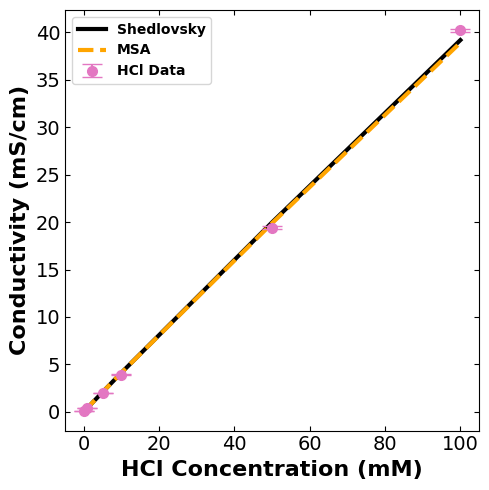

In [31]:
# making plot comparison of data and calculated values
fig = plt.figure(figsize=(5,5))
plt.plot(molar_conc_specific_H, specific_cond_calc_H, "-", color="black", linewidth=3, label="Shedlovsky")
plt.plot(molar_conc_specific_H, cond_HCl, "--", color="orange", linewidth=3, label="MSA")
plt.errorbar(
    molar_conc_specific_H, specific_cond_calibrated_H, yerr=error_H, fmt='o', ecolor='tab:pink', capsize=7, markersize=7, markerfacecolor='tab:pink',
    markeredgecolor='tab:pink', label='HCl Data')
plt.xlabel("HCl Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(".\Li_Co\msa_hcl_paper.png")
plt.show()

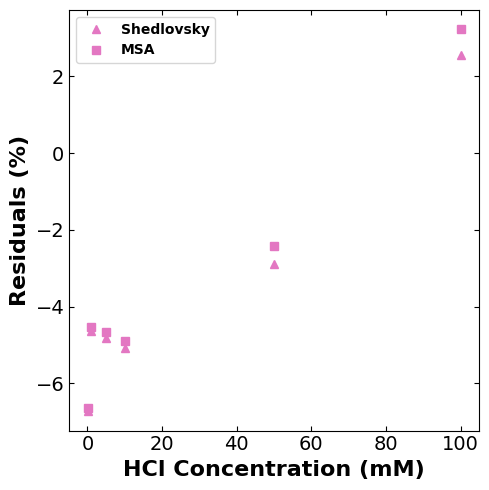

In [32]:
# visualizing in plot
fig = plt.figure(figsize=(5,5))
plt.plot(molar_conc_specific_H, residuals_percent_HCl_shed, "^", color="tab:pink", label="Shedlovsky")
plt.plot(molar_conc_specific_H, residuals_percent_HCl, "s", color="tab:pink", label="MSA")
plt.xlabel("HCl Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Li_Co\proportion_msa_hcl_paper.png")
plt.show()

## CoCl2

In [33]:
# loading CoCl2 specific conductivity data
specific_data = pd.read_csv("./Data/CoCl2.csv")
molar_conc_specific_Co = specific_data["Conc"]
specific_cond_Co_raw = specific_data["Cond"]

# number of data points
ndata_Co = len(specific_cond_Co_raw)

# convert the conductivity from micro Siemen per cm to milli Siemen per cm
specific_cond_Co = [specific_cond_Co_raw[i]/1000 for i in range(ndata_Co)]

# measurement error
error_Co = (-0.00007 * molar_conc_specific_Co + 0.0102) * specific_cond_Co

### Variant Shedlovsky Model

In [34]:
# concentration in M
conc_Co = [molar_conc_specific_Co[i]*10**(-3) for i in range(ndata_Co)]

# CoCl2 specific conductivity in milli Siemen per cm
specific_cond_calc_Co = cd.variant_shedlovsky(conc_Co, T, epsilon, eta_shed, lambda_0_CoCl2, a_CoCl2, z_Co, z_Cl, lambda_0_Co, lambda_0_Cl)

# residuals
e_CoCl2_shed = [specific_cond_Co[i] - specific_cond_calc_Co[i] for i in range(ndata_Co)]
print("Residuals:",e_CoCl2_shed)

# residuals percent or fraction
residuals_percent_CoCl2_shed = [100*e_CoCl2_shed[i]/specific_cond_Co[i] for i in range(ndata_Co)]
print("\nPercent errors:",residuals_percent_CoCl2_shed)

# absolute value of relative error
residuals_percent_CoCl2_abs_shed = [np.abs(residuals_percent_CoCl2_shed[i]) for i in range(ndata_Co)]
print("\nThe mean absolute percent error of CoCl2 is:", np.mean(residuals_percent_CoCl2_abs_shed))

# calculate the mean absolute error
e_CoCl2_abs_shed = [np.abs(e_CoCl2_shed[i]) for i in range(ndata_Co)]
print("\nThe mean absolute error of CoCl2 is:",np.mean(e_CoCl2_abs_shed))

# calculate the mean squared error
sq_residuals_CoCl2_shed = [e_CoCl2_shed[i]**2 for i in range(ndata_Co)]
print("\nThe mean squared error of HCl is:",np.mean(sq_residuals_CoCl2_shed))

Residuals: [-0.015346058003986474, -0.024240490091803624, -0.09698598174616468, -0.04904348358815236, -0.21555960544131203, -0.2597593143000285, -0.1805206996097093, -0.20865324362602244, -0.14134948390522695]

Percent errors: [-6.591666167255047, -4.198069012469888, -9.083636016312136, -2.24743303034334, -5.380515823610613, -5.291275855537124, -3.0538240253363775, -2.720452210305646, -1.4941647964104707]

The mean absolute percent error of CoCl2 is: 4.451226326397849

The mean absolute error of CoCl2 is: 0.13238426225693406

The mean squared error of HCl is: 0.02474211859122551


### MSA Model

In [35]:
# calculated conductivity in milli S/cm
cond_CoCl2 = cd.msa_transport(valency, diameter, diffusion_coeff, T, eta_msa, epsilon, lambda_0_Co_Cl, molar_conc_specific_Co)

# residuals
e_CoCl2 = [specific_cond_Co[i] - cond_CoCl2[i] for i in range(ndata_Co)]

# residuals percent or fraction
residuals_percent_CoCl2 = [100*e_CoCl2[i]/specific_cond_Co[i] for i in range(ndata_Co)]
print("\nPercent errors:",residuals_percent_CoCl2)

# absolute value of relative error
residuals_percent_CoCl2_abs = [np.abs(residuals_percent_CoCl2[i]) for i in range(ndata_Co)]
print("\nThe mean absolute percent error of CoCl2 is:", np.mean(residuals_percent_CoCl2_abs))

# calculate the mean absolute error
e_CoCl2_abs = [np.abs(e_CoCl2[i]) for i in range(ndata_Co)]
print("\nThe mean absolute error of CoCl2 is:",np.mean(e_CoCl2_abs))

# calculate the mean squared error
sq_residuals_CoCl2 = [e_CoCl2[i]**2 for i in range(ndata_Co)]
print("\nThe mean squared error of CoCl2 is:",np.mean(sq_residuals_CoCl2))

Relaxation correction: [-0.09585508 -0.09585508]
Hydrodynamic correction: [-0.3468368  -0.11287597]
omega_bar: 283022965378.78674
Alpha: [0.0, 346930734283.9881]
Mew: [0.66666667 0.33333333]
Transport number: [0.4187643 0.5812357]
Omega: [1.77779872e+11 4.93509152e+11]
ksi: [[ 1.42250053 -0.60371383]
 [ 0.51243621  1.20742767]]

Percent errors: [-6.4072860251369805, -3.9086095818563575, -8.604776459400538, -1.500349886922453, -4.072113222547859, -3.7402472496464756, -1.3093577407427688, -0.5592642261179734, 1.0284530755056367]

The mean absolute percent error of CoCl2 is: 3.4589397186530046

The mean absolute error of CoCl2 is: 0.08071602452065886

The mean squared error of CoCl2 is: 0.009763444955014007


## LiCl

In [36]:
# loading LiCl specific conductivity data
specific_data = pd.read_csv("./Data/LiCl.csv")
molar_conc_specific_Li = specific_data["Conc"]
specific_cond_Li_raw = specific_data["Cond"]

# number of data points
ndata_Li = len(specific_cond_Li_raw)

# convert the conductivity from micro Siemen per cm to milli Siemen per cm
specific_cond_Li = [specific_cond_Li_raw[i]/1000 for i in range(ndata_Li)]

# measurement error
error_Li = (-0.00007 * molar_conc_specific_Li + 0.0102) * specific_cond_Li

### Variant Shedlovsky model

In [37]:
# constants
lambda_0_LiCl = 114.95 # cm^2.Siemen.equiv^(-1)
lambda_0_Li = 38.6 # cm^2.Siemen.equiv^(-1)
a_LiCl = 5.2*10**(-8) # cm

In [38]:
# concentration in M
conc_Li = [molar_conc_specific_Li[i]*10**(-3) for i in range(ndata_Li)]

# LiCl specific conductivity in milli Siemen per cm
specific_cond_calc_Li = cd.variant_shedlovsky(conc_Li, T, epsilon, eta_shed, lambda_0_LiCl, a_LiCl, z_Li, z_Cl, lambda_0_Li, lambda_0_Cl)

# residuals
e_LiCl_shed = [specific_cond_Li[i] - specific_cond_calc_Li[i] for i in range(ndata_Li)]
print("Residuals:",e_LiCl_shed)

# residuals percent or fraction
residuals_percent_LiCl_shed = [100*e_LiCl_shed[i]/specific_cond_Li[i] for i in range(ndata_Li)]
print("\nPercent errors:",residuals_percent_LiCl_shed)

# absolute value of relative error
residuals_percent_LiCl_abs_shed = [np.abs(residuals_percent_LiCl_shed[i]) for i in range(ndata_Li)]
print("\nThe mean absolute percent error of LiCl is:", np.mean(residuals_percent_LiCl_abs_shed))

# calculate the mean absolute error
e_LiCl_abs_shed = [np.abs(e_LiCl_shed[i]) for i in range(ndata_Li)]
print("\nThe mean absolute error of HCl is:",np.mean(e_LiCl_abs_shed))

# calculate the mean squared error
sq_residuals_LiCl_shed = [e_LiCl_shed[i]**2 for i in range(ndata_Li)]
print("\nThe mean squared error of HCl is:",np.mean(sq_residuals_LiCl_shed))

Residuals: [-0.006040226454107983, -0.02343763109255831, -0.04126185012482764, -0.06011270485765663, -0.08826891089061517, -0.11367535474985146, -0.14997324167733073, -0.20223212519936817, -0.25184358092740844]

Percent errors: [-5.682245017975525, -9.230321003685535, -8.153710132363925, -5.9218505425728125, -4.385814910594016, -4.566375622634026, -5.084183391325877, -5.215932250061079, -5.255390766624411]

The mean absolute percent error of LiCl is: 5.943980404204133

The mean absolute error of HCl is: 0.10409395844152496

The mean squared error of HCl is: 0.0170478184768217


### MSA model

In [39]:
# calculated conductivity in milli S/cm
cond_LiCl = cd.msa_transport(valency_LiCl, diameter_LiCl, diffusion_coeff_LiCl, T, eta, epsilon, lambda_0_Li_Cl, molar_conc_specific_Li)

# residuals
e_LiCl = [specific_cond_Li[i] - cond_LiCl[i] for i in range(ndata_Li)]

# residuals percent or fraction
residuals_percent_LiCl = [100*e_LiCl[i]/specific_cond_Li[i] for i in range(ndata_Li)]
print("\nPercent errors:",residuals_percent_LiCl)

# absolute value of relative error
residuals_percent_LiCl_abs = [np.abs(residuals_percent_LiCl[i]) for i in range(ndata_Li)]
print("\nThe mean absolute percent error of LiCl is:", np.mean(residuals_percent_LiCl_abs))

# calculate the mean absolute error
e_LiCl_abs = [np.abs(e_LiCl[i]) for i in range(ndata_Li)]
print("\nThe mean absolute error of LiCl is:",np.mean(e_LiCl_abs))

# calculate the mean squared error
sq_residuals_LiCl = [e_LiCl[i]**2 for i in range(ndata_Li)]
print("\nThe mean squared error of LiCl is:",np.mean(sq_residuals_LiCl))

Relaxation correction: [-0.03801212 -0.03801212]
Hydrodynamic correction: [-0.15302411 -0.0725485 ]
omega_bar: 371710510737.0421
Alpha: [0.0, 351189115250.81476]
Mew: [0.5 0.5]
Transport number: [0.33616465 0.66383535]
Omega: [2.49911869e+11 4.93509152e+11]
ksi: [[ 1.40525185 -1.        ]
 [ 0.71161622  1.        ]]

Percent errors: [-5.592794848081536, -9.080636201197487, -7.916254069158372, -5.5269038711696625, -3.707602064981614, -3.7532282543374422, -4.138296461397767, -4.025314622936553, -3.8362702422793755]

The mean absolute percent error of LiCl is: 5.286366737282202

The mean absolute error of LiCl is: 0.08391082605124267

The mean squared error of LiCl is: 0.010296962452434147


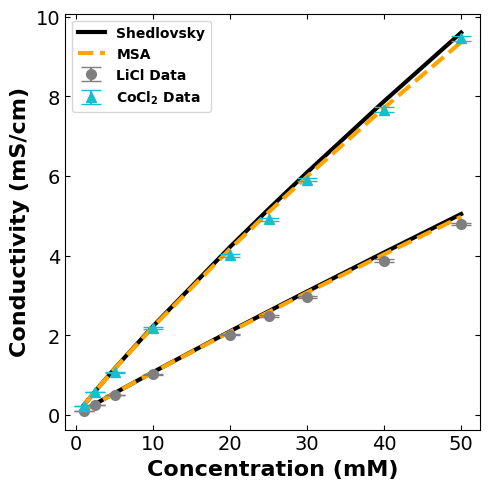

In [40]:
# making plot comparison of data and calculated values
fig = plt.figure(figsize=(5,5))
plt.plot(molar_conc_specific_Li, specific_cond_calc_Li, "-", color="black", linewidth=3, label="Shedlovsky")
plt.plot(molar_conc_specific_Co, specific_cond_calc_Co, "-", color="black", linewidth=3)
plt.plot(molar_conc_specific_Li, cond_LiCl, "--", color="orange", linewidth=3, label="MSA")
plt.plot(molar_conc_specific_Co, cond_CoCl2, "--", color="orange", linewidth=3)
plt.errorbar(
    molar_conc_specific_Li, specific_cond_Li, yerr=error_Li, fmt='o', ecolor='tab:gray', capsize=7, markersize=7, markerfacecolor='tab:gray',
    markeredgecolor='tab:gray', label='LiCl Data')
plt.errorbar(
    molar_conc_specific_Co, specific_cond_Co, yerr=error_Co, fmt='^', ecolor='tab:cyan', capsize=7, markersize=7, markerfacecolor='tab:cyan',
    markeredgecolor='tab:cyan', label='CoCl$\mathbf{_2}$ Data')
plt.xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(".\Li_Co\msa_li_co_paper.png")
plt.show()

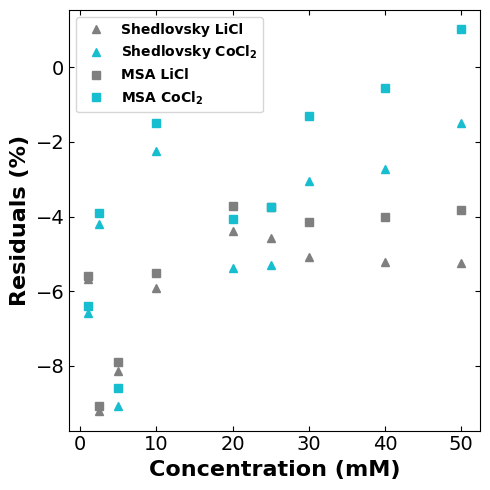

In [41]:
# visualizing the percent errors
fig = plt.figure(figsize=(5,5))
plt.plot(molar_conc_specific_Li, residuals_percent_LiCl_shed, "^", color="tab:gray", label="Shedlovsky LiCl")
plt.plot(molar_conc_specific_Co, residuals_percent_CoCl2_shed, "^", color="tab:cyan", label="Shedlovsky CoCl$\mathbf{_2}$")
plt.plot(molar_conc_specific_Li, residuals_percent_LiCl, "s", color="tab:gray", label="MSA LiCl")
plt.plot(molar_conc_specific_Co, residuals_percent_CoCl2, "s", color="tab:cyan", label="MSA CoCl$\mathbf{_2}$")
plt.xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Li_Co\proportion_msa_li_co_paper.png")
plt.show()

## CoCl2 pH 3

In [42]:
# loading CoCl2 specific conductivity data
specific_data = pd.read_csv("./Data/CoCl2_ph3_calibration.csv")
molar_conc_specific_Co_ph3 = specific_data["Conc"]
specific_cond_Co_ph3_raw = specific_data["Cond"]

# number of data points
ndata_Co_ph3 = len(specific_cond_Co_ph3_raw)

# convert the conductivity from micro Siemen per cm to milli Siemen per cm
specific_cond_Co_ph3 = [specific_cond_Co_ph3_raw[i]/1000 for i in range(ndata_Co_ph3)]

# measurement error
error_Co_ph3 = (-0.00007 * molar_conc_specific_Co_ph3 + 0.0102) * specific_cond_Co_ph3

In [43]:
# calculate the H+ concentration from pH 3
H_conc_ph3_single = 1000 * (10 ** (-3))
H_conc_ph3 = [H_conc_ph3_single for i in range(ndata_Co_ph3)]

### MSA model

In [44]:
msa_cond_Co_H_ph3 = msa_transport(valency_Co_Cl_H, diameter_Co_Cl_H, diff_coeff_Co_Cl_H, temp, eta_msa, epsilon_msa, lambda_0_Co_Cl_H, 
                                    molar_conc_specific_Co_ph3, H_conc_ph3)

# residuals
e_CoCl2_ph3_msa = [specific_cond_Co_ph3[i] - msa_cond_Co_H_ph3[i] for i in range(ndata_Co_ph3)]

# residuals percent or fraction
residuals_percent_CoCl2_ph3_msa = [100*e_CoCl2_ph3_msa[i]/specific_cond_Co_ph3[i] for i in range(ndata_Co_ph3)]
print("\nPercent errors:",residuals_percent_CoCl2_ph3_msa)

# absolute value of relative error
residuals_percent_CoCl2_ph3_abs_msa = [np.abs(residuals_percent_CoCl2_ph3_msa[i]) for i in range(ndata_Co_ph3)]
print("\nThe mean absolute percent error of CoCl2 at pH 3 is:", np.mean(residuals_percent_CoCl2_ph3_abs_msa))

# calculate the mean absolute error
e_CoCl2_ph3_abs_msa = [np.abs(e_CoCl2_ph3_msa[i]) for i in range(ndata_Co_ph3)]
print("\nThe mean absolute error of CoCl2 at pH 3 is:",np.mean(e_CoCl2_ph3_abs_msa))

# calculate the mean squared error
sq_residuals_CoCl2_ph3_msa = [e_CoCl2_ph3_msa[i]**2 for i in range(ndata_Co_ph3)]
print("\nThe mean squared error of HCl is:",np.mean(sq_residuals_CoCl2_ph3_msa))

Scaled omega:  [0.31938915 0.88661031 4.06261249]
Scaled omega:  [0.43173854 1.19848732 5.49169066]
Scaled omega:  [0.50588515 1.40431506 6.43483144]
Scaled omega:  [0.55848295 1.55032426 7.10387261]
Scaled omega:  [0.59070134 1.63976108 7.51368871]
Scaled omega:  [0.597734   1.65928345 7.60314382]
Scaled omega:  [0.60254271 1.67263221 7.6643103 ]
Scaled omega:  [0.60869416 1.68970837 7.74255643]
Scaled omega:  [0.61246236 1.70016872 7.79048769]
Relaxation correction: [-0.09525431 -0.09587202 -0.15764306]
Hydrodynamic correction: [-0.34779141 -0.11315769 -0.02854367]
omega_bar: 290270692123.20825
Alpha: [0.0, 346107165035.93506, 2232902704859.152]
Mew: [0.66225166 0.33443709 0.00331126]
Transport number: [0.40560421 0.56859947 0.02579632]
Omega: [1.77779872e+11 4.93509152e+11 2.26135026e+12]
ksi: [[ 1.44405141 -0.61645254 -0.01262644]
 [ 0.52019962  1.21932718 -0.03661693]
 [ 0.11352654  0.13846371  6.22359731]]

Percent errors: [6.454293360418137, 9.135282990552371, -2.362690999510069

### Shedlovsky model

In [45]:
# concentration in M
conc_Co_ph3 = [molar_conc_specific_Co_ph3[i] * 10**(-3) for i in range(ndata_Co_ph3)]
H_conc_ph3_molar = [H_conc_ph3[i] * 10**(-3) for i in range(ndata_Co_ph3)]

# CoCl2 specific conductivity at pH 3 in milli Siemen per cm
specific_cond_calc_Co_ph3 = cd.variant_shedlovsky(conc_Co_ph3, T, epsilon, eta_shed, lambda_0_CoCl2, a_H_Co, z_Co, z_Cl, lambda_0_Co, lambda_0_Cl)

# HCl specific conductivity at pH 3 in milli Siemen per cm
specific_cond_calc_H_ph3 = cd.variant_shedlovsky(H_conc_ph3_molar, T, epsilon, eta_shed, lambda_0_HCl, a_H_Co, z_H, z_Cl, lambda_0_H, lambda_0_Cl)

# bulk conductivity at pH 3 in milli Siemen per cm
specific_cond_calc_Co_H_ph3 = [specific_cond_calc_Co_ph3[i] + specific_cond_calc_H_ph3[i] for i in range(ndata_Co_ph3)]

# residuals
e_CoCl2_ph3_shed = [specific_cond_Co_ph3[i] - specific_cond_calc_Co_H_ph3[i] for i in range(ndata_Co_ph3)]

# residuals percent or fraction
residuals_percent_CoCl2_ph3_shed = [100*e_CoCl2_ph3_shed[i]/specific_cond_Co_ph3[i] for i in range(ndata_Co_ph3)]
print("\nPercent errors:",residuals_percent_CoCl2_ph3_shed)

# absolute value of relative error
residuals_percent_CoCl2_ph3_abs_shed = [np.abs(residuals_percent_CoCl2_ph3_shed[i]) for i in range(ndata_Co_ph3)]
print("\nThe mean absolute percent error of CoCl2 at pH 3 is:", np.mean(residuals_percent_CoCl2_ph3_abs_shed))

# calculate the mean absolute error
e_CoCl2_ph3_abs_shed = [np.abs(e_CoCl2_ph3_shed[i]) for i in range(ndata_Co_ph3)]
print("\nThe mean absolute error of CoCl2 at pH 3 is:",np.mean(e_CoCl2_ph3_abs_shed))

# calculate the mean squared error
sq_residuals_CoCl2_ph3_shed = [e_CoCl2_ph3_shed[i]**2 for i in range(ndata_Co_ph3)]
print("\nThe mean squared error of HCl is:",np.mean(sq_residuals_CoCl2_ph3_shed))


Percent errors: [4.845542350324674, 7.265551864327432, -4.514247002954003, 5.0078058501639715, -4.454048474514591, -3.0462143794325844, -2.387774255164895, -1.9803000896791998, -1.3904043115850648]

The mean absolute percent error of CoCl2 at pH 3 is: 3.876876508682935

The mean absolute error of CoCl2 at pH 3 is: 0.12616576317314493

The mean squared error of HCl is: 0.01844605483288958


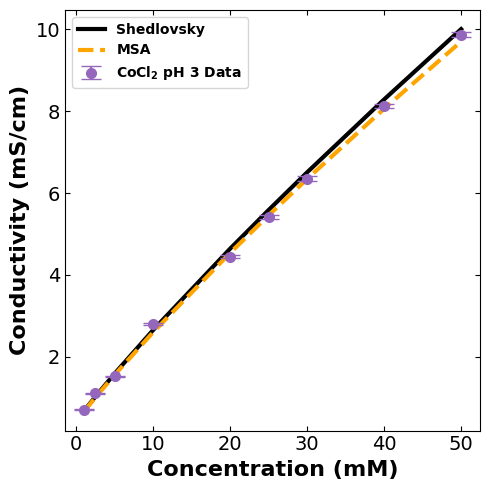

In [46]:
# making plot comparison of data and calculated values
fig = plt.figure(figsize=(5,5))
plt.plot(molar_conc_specific_Co_ph3, specific_cond_calc_Co_H_ph3, "-", color="black", linewidth=3, label="Shedlovsky")
plt.plot(molar_conc_specific_Co_ph3, msa_cond_Co_H_ph3, "--", color="orange", linewidth=3, label="MSA")
plt.errorbar(
    molar_conc_specific_Co_ph3, specific_cond_Co_ph3, yerr=error_Co_ph3, fmt='o', ecolor='tab:purple', capsize=7, markersize=7, 
    markerfacecolor='tab:purple', markeredgecolor='tab:purple', label='CoCl$\mathbf{_2}$ pH 3 Data')
plt.xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(".\Li_Co\msa_shed_co_h_ph3_paper.png")
plt.show()

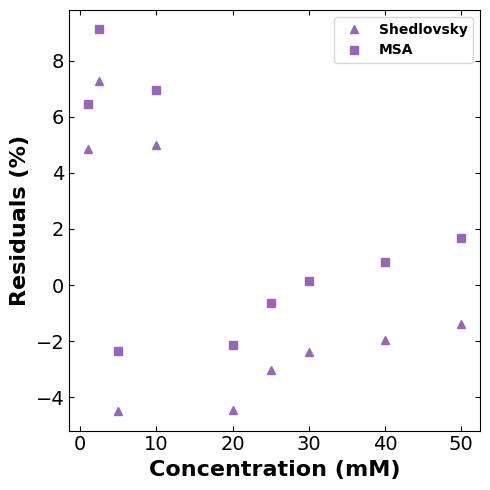

In [47]:
# visualizing the percent errors
fig = plt.figure(figsize=(5,5))
plt.plot(molar_conc_specific_Co_ph3, residuals_percent_CoCl2_ph3_shed, "^", color="tab:purple", label="Shedlovsky")
plt.plot(molar_conc_specific_Co_ph3, residuals_percent_CoCl2_ph3_msa, "s", color="tab:purple", label="MSA")
plt.xlabel("Concentration (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Li_Co\proportion_msa_shed_co_h_ph3_paper.png")
plt.show()